<a href="https://colab.research.google.com/github/esdras-vinicius/analise-reviews-amazon/blob/main/analise_reviews_amazon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Projeto  — Recuperação da Informação em Avaliações de Produtos Alimentícios

**Dataset:** Amazon Fine Food Reviews  


## Seção 1: Introdução

### 1.1 Contextualização

> **+568 mil avaliações** publicadas entre 1999 e 2012 | **~13% dos produtos** com ao menos uma reclamação de segurança alimentar | fonte: Stanford SNAP

O comércio eletrônico de alimentos gera diariamente um volume massivo de avaliações de consumidores. Dentro desse volume, uma fração pequena, mas crítica, relata falhas graves de segurança e logística, como produtos vencidos, embalagens violadas e sinais de contaminação. Identificar essas avaliações manualmente é inviável na escala de plataformas como a Amazon.

Este projeto aplica técnicas de **Recuperação da Informação (Information Retrieval)** para automatizar a triagem dessas reclamações críticas. A ideia central é a mesma de um sistema de busca: dado um conjunto de termos que descrevem um problema (a *query*), queremos ranquear as avaliações mais relevantes no topo, separando relatos de falhas reais de reclamações subjetivas ou genéricas.

### 1.2 Objetivo

**Pergunta central da análise:**

> *"O uso de métricas probabilísticas de peso, como TF-IDF e BM25, consegue ranquear avaliações que descrevem falhas reais de segurança alimentar com maior precisão do que uma busca simples por palavras-chave?"*

**Hipótese inicial:**  
Acreditamos que métricas como TF-IDF e BM25 isolam termos com alto valor informativo (termos raros que indicam problemas específicos) de forma mais precisa do que uma busca ingênua, porque penalizam termos comuns e valorizam termos que concentram poder discriminativo dentro da coleção de documentos.

### 1.3 Descrição dos Dados

**Fonte:** [Amazon Fine Food Reviews — Kaggle](https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews)  
**Origem:** Stanford Network Analysis Project (SNAP)  
**Período coberto:** Outubro de 1999 a Outubro de 2012  
**Dimensões originais:** ~568.454 linhas × 10 colunas  

**Por que este dataset?**  
Escolhido pela alta usabilidade no Kaggle (score 9.2), volume representativo para técnicas de IR, presença do campo `Text` com linguagem natural rica, e disponibilidade da variável `Score` como referência de validação estatística.

#### ⚠️ Caveat estrutural importante

Cada linha representa **uma avaliação de um usuário**, não um produto único. O mesmo `ProductId` aparece em múltiplas linhas, escritas por usuários diferentes. Isso significa que, nas etapas seguintes, trataremos cada review individualmente como um **documento** do corpus — e não agruparemos por produto sem uma agregação explícita.

#### Dicionário de Dados

| Coluna | Tipo | Descrição |
|---|---|---|
| `Id` | Inteiro | Identificador único da avaliação |
| `ProductId` | Caractere | Identificador único do produto avaliado |
| `UserId` | Caractere | Identificador único do usuário que avaliou |
| `ProfileName` | Caractere | Nome de perfil do usuário |
| `HelpfulnessNumerator` | Inteiro | Nº de usuários que acharam a avaliação útil |
| `HelpfulnessDenominator` | Inteiro | Nº total de usuários que votaram na avaliação |
| `Score` | Inteiro | Nota dada ao produto (escala de 1 a 5 estrelas) |
| `Time` | Inteiro | Timestamp Unix da avaliação |
| `Summary` | Caractere | Título curto da avaliação escrito pelo usuário |
| `Text` | Caractere | Corpo completo da avaliação — **variável principal** |

> **Variáveis de interesse primário:** `Score` e `Text`. O campo `Text` é o corpus sobre o qual aplicaremos TF-IDF e BM25. O campo `Score` será usado como rótulo de referência para validação estatística.

In [ ]:
# Instalação dos pacotes necessários para o projeto completo
# Execute esta célula apenas uma vez por sessão

install.packages(c(
  "data.table",   # leitura eficiente de CSV grandes
  "dplyr",        # manipulação de dados
  "tidytext",     # mineração de texto no estilo tidy
  "ggplot2",      # visualizações
  "stringr",      # manipulação de strings
  "stopwords",    # lista de stopwords em inglês
  "scales",       # formatação de eixos nos gráficos
  "knitr",        # tabelas formatadas no notebook
  "SnowballC"     # stemming (será usado no pré-processamento)
))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘janeaustenr’, ‘tokenizers’, ‘ISOcodes’




In [ ]:
library(data.table)
library(dplyr)
library(tidytext)
library(ggplot2)
library(stringr)
library(stopwords)
library(scales)
library(knitr)
library(SnowballC)


Attaching package: ‘data.table’


The following object is masked from ‘package:base’:

    %notin%



Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




#### Carregamento do Dataset

O dataset será carregado diretamente do Kaggle via API. Para isso, é necessário ter o arquivo `kaggle.json` com suas credenciais, gerado em [kaggle.com/settings](https://www.kaggle.com/settings) → **API** → **Create New Token**.

Após baixar o `kaggle.json`, faça o upload manual dele na pasta `/content/` do Colab usando o ícone de pasta na barra lateral. A célula abaixo cuida do restante automaticamente.

In [ ]:
# Passo 1: instalar o cliente do Kaggle (via terminal do Colab)
system("pip install kaggle -q", intern = TRUE)

# Passo 2: configurar a autenticação
# Você precisa do arquivo kaggle.json gerado no seu perfil Kaggle:
# kaggle.com > seu perfil > Settings > API > Create New Token
# Isso baixa um arquivo kaggle.json com seu usuário e chave.

# Crie a pasta e suba o kaggle.json manualmente UMA VEZ:
system("mkdir -p ~/.kaggle", intern = TRUE)

# Depois do upload manual do kaggle.json, ajuste as permissões:
system("cp /content/kaggle.json ~/.kaggle/kaggle.json", intern = TRUE)
system("chmod 600 ~/.kaggle/kaggle.json", intern = TRUE)

# Passo 3: baixar o dataset direto do Kaggle
system("kaggle datasets download -d snap/amazon-fine-food-reviews --unzip -p /content/", intern = TRUE)

# Passo 4: carregar
library(data.table)
df <- fread("/content/Reviews.csv",
            select = c("Id", "ProductId", "UserId",
                       "Score", "Summary", "Text", "Time"),
            encoding = "UTF-8")

cat("Linhas:", nrow(df), "| Colunas:", ncol(df), "\n")

character(0)

character(0)

Warning message in system("cp /content/kaggle.json ~/.kaggle/kaggle.json", intern = TRUE):
“running command 'cp /content/kaggle.json ~/.kaggle/kaggle.json' had status 1”


character(0)
attr(,"status")
[1] 1
attr(,"errmsg")
[1] "Resource temporarily unavailable"

Warning message in system("chmod 600 ~/.kaggle/kaggle.json", intern = TRUE):
“running command 'chmod 600 ~/.kaggle/kaggle.json' had status 1”


character(0)
attr(,"status")
[1] 1
attr(,"errmsg")
[1] "Resource temporarily unavailable"

[1] "Warning: Looks like you're using an outdated `kaggle` version (installed: 2.0.2), please consider upgrading to the latest version (2.2.2)"
[2] "Dataset URL: https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews"                                                               
[3] "License(s): CC0-1.0"                                                                                                                      
[4] "Downloading amazon-fine-food-reviews.zip to /content"                                                                                     
[5] ""

Linhas: 568454 | Colunas: 7 


In [ ]:
# Visão geral da estrutura
glimpse(df)

Rows: 568,454
Columns: 7
$ Id        <int> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 1…
$ ProductId <chr> "B001E4KFG0", "B00813GRG4", "B000LQOCH0", "B000UA0QIQ", "B00…
$ UserId    <chr> "A3SGXH7AUHU8GW", "A1D87F6ZCVE5NK", "ABXLMWJIXXAIN", "A395BO…
$ Score     <int> 5, 1, 4, 2, 5, 4, 5, 5, 5, 5, 5, 5, 1, 4, 5, 5, 2, 5, 5, 5, …
$ Summary   <chr> "Good Quality Dog Food", "Not as Advertised", "\"\"Delight\"…
$ Text      <chr> "I have bought several of the Vitality canned dog food produ…
$ Time      <int> 1303862400, 1346976000, 1219017600, 1307923200, 1350777600, …


In [ ]:
# Resumo estatístico das colunas numéricas
summary(df[, .(Score, Id)])

     Score             Id        
 Min.   :1.000   Min.   :     1  
 1st Qu.:4.000   1st Qu.:142114  
 Median :5.000   Median :284228  
 Mean   :4.183   Mean   :284228  
 3rd Qu.:5.000   3rd Qu.:426341  
 Max.   :5.000   Max.   :568454  

In [ ]:
# Verificação de valores ausentes por coluna
na_counts <- sapply(df, function(x) sum(is.na(x)))
kable(data.frame(Coluna = names(na_counts), Ausentes = na_counts),
      caption = "Contagem de valores ausentes por coluna",
      row.names = FALSE)



Table: Contagem de valores ausentes por coluna

|Coluna    | Ausentes|
|:---------|--------:|
|Id        |        0|
|ProductId |        0|
|UserId    |        0|
|Score     |        0|
|Summary   |        0|
|Text      |        0|
|Time      |        0|

In [ ]:
# Visualização das primeiras avaliações
df %>%
  select(Id, Score, Summary, Text) %>%
  head(5) %>%
  mutate(Text = str_trunc(Text, 120)) %>%  # trunca para caber na tela
  kable(caption = "Primeiras 5 avaliações do dataset")



Table: Primeiras 5 avaliações do dataset

| Id| Score|Summary                 |Text                                                                                                                     |
|--:|-----:|:-----------------------|:------------------------------------------------------------------------------------------------------------------------|
|  1|     5|Good Quality Dog Food   |I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The pro... |
|  2|     1|Not as Advertised       |Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this wa... |
|  3|     4|""Delight"" says it all |This is a confection that has been around a few centuries.  It is a light, pillowy citrus gelatin with nuts - in this... |
|  4|     2|Cough Medicine          |If you are looking for the secret ingredient in Robitussin I believe I have found it.  I got this in addition to the ..

> **Observação:** A Seção 2 (Análise Exploratória de Dados) dará continuidade a partir deste ponto, investigando a distribuição da variável `Score`, o comprimento dos textos e a presença de termos críticos de segurança alimentar.

## Seção 2: Análise Exploratória de Dados (EDA)

A Análise Exploratória de Dados constitui uma etapa metodológica indispensável para a condução de qualquer projeto rigoroso de estatística e análise dos dados. Antes de procedermos ao desenvolvimento, treinamento ou avaliação de qualquer modelo preditivo, é imperativo compreender de maneira profunda a topologia da informação com a qual estamos lidando. Esta fase tem como objetivo principal revelar a estrutura subjacente, o comportamento intrínseco e os padrões ocultos presentes no *corpus* de dados, permitindo a formulação de hipóteses fundamentadas e a identificação de eventuais anomalias ou ruídos que possam comprometer as etapas subsequentes.

Neste contexto, a nossa investigação apoia-se fortemente nos fundamentos de estatística descritiva, servindo como uma aplicação prática e direta dos conceitos teóricos revisados ao longo das aulas. O escopo desta análise engloba a utilização detalhada de medidas de tendência central e de posição, notadamente a média, a mediana e a moda, que nos fornecerão o ponto de equilíbrio e o comportamento esperado das variáveis estudadas. De forma complementar e igualmente essencial, aplicaremos medidas de dispersão, como a variância e o desvio padrão, para quantificar a variabilidade, a amplitude e a consistência das informações, dimensionando o quão dispersos os dados estão em relação aos seus valores centrais.


### 2.1 Carregamento e Limpeza dos Dados

Verificamos a integridade do dataset antes de qualquer análise: valores ausentes, duplicatas e inconsistências estruturais. Como cada linha representa **uma avaliação individual** (não um produto), duplicatas são identificadas pelo campo `Id`.

In [ ]:
# Dimensões do dataset
cat("Dimensões:", nrow(df), "linhas ×", ncol(df), "colunas\n\n")

# Verificação de valores ausentes por coluna
na_counts <- colSums(is.na(df))
cat("=== Valores Ausentes ===\n")
print(na_counts)

# Verificação de duplicatas por Id
n_dup <- sum(duplicated(df$Id))
cat("\nReviews duplicadas (mesmo Id):", n_dup, "\n")

# Verificação de reviews sem texto
n_sem_texto <- sum(is.na(df$Text) | trimws(df$Text) == "")
cat("Reviews sem texto:", n_sem_texto, "\n")

# Verificação do intervalo de Score
cat("\nValores únicos de Score:", sort(unique(df$Score)), "\n")

Dimensões: 568454 linhas × 7 colunas

=== Valores Ausentes ===
       Id ProductId    UserId     Score   Summary      Text      Time 
        0         0         0         0         0         0         0 

Reviews duplicadas (mesmo Id): 0 
Reviews sem texto: 0 

Valores únicos de Score: 1 2 3 4 5 


A avaliação preliminar da integridade do *corpus* revela um conjunto de dados de porte robusto, estruturado em uma matriz de 568.454 observações e 7 atributos explicativos ou de identificação (tais como *Id*, *ProductId*, *UserId*, *Score*, *Summary*, *Text* e *Time*). Do ponto de vista da qualidade da informação, os resultados obtidos atestam uma base de dados excepcionalmente limpa. A inspeção de dados faltantes (*missing values*) indicou preenchimento total em todas as variáveis, dispensando, neste primeiro momento, a aplicação de técnicas  de imputação de dados.

Somado a isso, a verificação de integridade estrutural confirmou a total ausência de registros duplicados com base no identificador único das instâncias (*Id*).

Por fim, a investigação da variável *Score*, validou o seu comportamento categórico ordinal. A distribuição dessa métrica limita-se estritamente aos valores discretos de 1 a 5, assim garantindo que os dados são represntativos de todas classes, assegurando que a base de dados pode ser utilizada para a análise.

In [ ]:
# Remoção de linhas com texto ausente (se houver)
df <- df[!is.na(df$Text) & trimws(df$Text) != "", ]

# Remoção de duplicatas por Id
df <- df[!duplicated(df$Id), ]

# Criação da variável auxiliar: comprimento do texto (nº de palavras)
df$n_palavras <- stringr::str_count(df$Text, "\\S+")

cat("Dataset após limpeza:", nrow(df), "linhas\n")
cat("Nova variável criada: n_palavras\n")
summary(df$n_palavras)

Dataset após limpeza: 568454 linhas
Nova variável criada: n_palavras


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   3.00   33.00   56.00   80.26   98.00 3432.00 

A aplicação de filtros para a remoção de valores ausentes, *strings* vazias e registros duplicados por identificador não resultou em qualquer redução do tamanho da amostra, mantendo o *corpus* intacto com suas 568.454 observações originais. Esse procedimento ratifica a confiabilidade do *dataset* para as etapas analíticas subsequentes.

O passo metodológico seguinte consistiu na extração de características (*feature engineering*), especificamente a criação de uma nova variável representativa do comprimento de cada documento, mensurada pela contagem de palavras (*n_palavras*). A análise das estatísticas descritivas dessa variável revela *insights* fundamentais sobre o comportamento morfológico das avaliações. Inicialmente, constata-se um valor mínimo de 3 palavras, garantindo que todas as instâncias possuem algum conteúdo semântico válido e eliminando a preocupação com entradas que contivessem apenas espaços ou caracteres isolados.

Ao avaliarmos as medidas de tendência central, observa-se que a mediana (56 palavras) é consideravelmente inferior à média (aproximadamente 80 palavras). Essa divergência entre as métricas sinaliza uma distribuição de frequência com assimetria positiva (enviesada à direita). Tal comportamento é fortemente tracionado pela presença de valores discrepantes (*outliers*) na cauda superior da distribuição, o que fica evidente ao notarmos um valor máximo extremo de 3.432 palavras.



### 2.2 Análise Univariada

Nesta subseção, conduzimos a exploração detalhada de cada variável de forma individualizada, buscando compreender suas propriedades intrínsecas antes de avaliar suas interações. Conforme os preceitos estatísticos discutidos em sala de aula, a análise da distribuição de frequências consubstancia-se como o método mais eficaz para descrever o comportamento isolado de uma variável no espaço amostral. A escolha da representação visual obedece rigorosamente à natureza dos dados: empregamos o histograma como a ferramenta gráfica ideal para modelar a densidade e a forma de variáveis quantitativas (contínuas ou com alta cardinalidade), enquanto o gráfico de barras é o instrumento mais indicado para representar a frequência de variáveis categóricas ou qualitativas.

Sob essa diretriz metodológica, a nossa investigação univariada concentra-se no exame de três eixos analíticos principais. Primeiramente, avaliamos a distribuição das notas dos usuários (**Score**), tratando-a como uma variável categórica ordinal para entender o viés geral de satisfação presente na base. Em um segundo momento, analisamos o comportamento da variável contínua referente ao comprimento dos textos (**n_palavras**), mapeando a dispersão e a centralidade da verbosidade das avaliações. Por fim, quantificamos a frequência de incidência de termos críticos de segurança ao longo do *corpus*, uma etapa analítica fundamental para dimensionar a prevalência de relatos associados a potenciais riscos ou defeitos graves nos produtos.

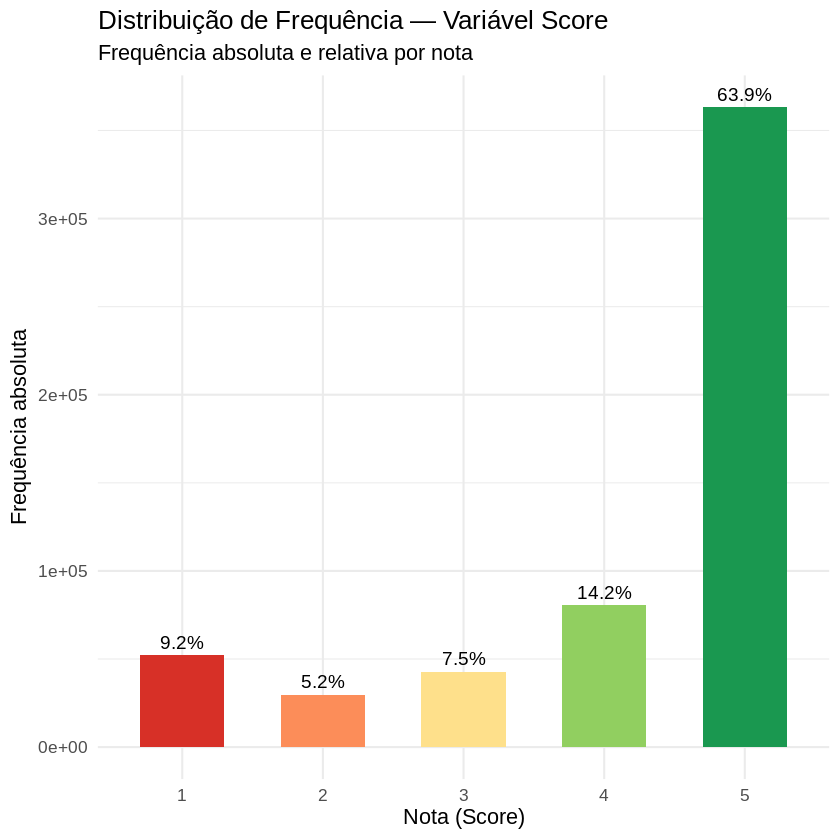

In [ ]:
library(ggplot2)
library(dplyr)
library(scales)

# --- Gráfico 1: Distribuição de Score ---
score_freq <- df %>%
  count(Score) %>%
  mutate(prop = n / sum(n) * 100)

ggplot(score_freq, aes(x = factor(Score), y = n, fill = factor(Score))) +
  geom_col(width = 0.6, show.legend = FALSE) +
  geom_text(aes(label = paste0(round(prop, 1), "%")),
            vjust = -0.5, size = 4) +
  scale_fill_manual(values = c("#d73027","#fc8d59","#fee08b","#91cf60","#1a9850")) +
  labs(title = "Distribuição de Frequência — Variável Score",
       subtitle = "Frequência absoluta e relativa por nota",
       x = "Nota (Score)", y = "Frequência absoluta") +
  theme_minimal(base_size = 13)

### Análise da Distribuição da Variável *Score* e Implicações para a Recuperação de Informação

A inspeção visual do gráfico de barras referente à variável *Score* revela uma característica estrutural determinante do nosso *corpus*: um **severo desbalanceamento de classes** com forte assimetria à esquerda. Observa-se que as avaliações estão maciçamente concentradas no espectro positivo, com a nota máxima (5 estrelas) representando 63,9% do volume total de dados, seguida pela nota 4 com 14,2%. Em contrapartida, as avaliações negativas (notas 1 e 2), que logicamente abrigam a vasta maioria dos relatos sobre falhas de segurança alimentar, constituem uma pequena fração minoritária do *dataset* (aproximadamente 14,4% somadas).



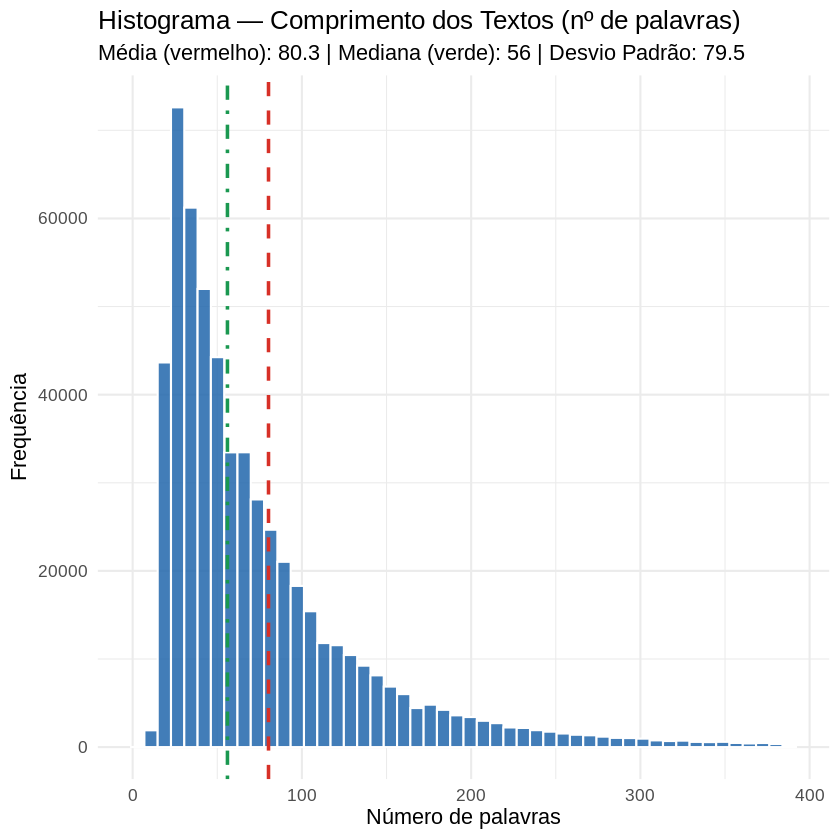

In [ ]:
# --- Gráfico 2: Histograma do comprimento dos textos ---
# Filtramos outliers extremos para melhor visualização (p99)
limite_p99 <- quantile(df$n_palavras, 0.99)

df_plot <- df %>% filter(n_palavras <= limite_p99)

ggplot(df_plot, aes(x = n_palavras)) +
  geom_histogram(bins = 50, fill = "#2166ac", color = "white", alpha = 0.85) +
  geom_vline(aes(xintercept = mean(df$n_palavras)),
             color = "#d73027", linetype = "dashed", linewidth = 1,
             show.legend = TRUE) +
  geom_vline(aes(xintercept = median(df$n_palavras)),
             color = "#1a9850", linetype = "dotdash", linewidth = 1) +
  labs(title = "Histograma — Comprimento dos Textos (nº de palavras)",
       subtitle = paste0("Média (vermelho): ", round(mean(df$n_palavras), 1),
                         " | Mediana (verde): ", median(df$n_palavras),
                         " | Desvio Padrão: ", round(sd(df$n_palavras), 1)),
       x = "Número de palavras", y = "Frequência") +
  theme_minimal(base_size = 13)

O presente histograma evidencia a distribuição com forte assimetria positiva (*right-skewed*) referente à contagem de palavras nas avaliações. A nítida separação entre a mediana (56 palavras) e a média (80,3 palavras), aliada a um expressivo desvio padrão (79,5), atesta que o *corpus* é majoritariamente composto por relatos muito concisos. Contudo, a presença de uma longa cauda à direita demonstra a existência de um subconjunto de avaliações altamente verbosas e extensas.


### Análise Morfológica do Corpus e o Desafio da Variância de Comprimento

O histograma em apreço ilustra a densidade de distribuição da variável referente ao comprimento dos textos (*n_palavras*). A representação gráfica atesta visualmente a forte **assimetria positiva** (enviesamento à direita) inferida durante as etapas de estatística descritiva. A evidente defasagem espacial entre a mediana (linha verde, fixada em 56 palavras) e a média (linha tracejada vermelha, tracionada para 80,3 palavras) comprova o viés exercido pela cauda longa da distribuição, que abriga um volume minoritário de avaliações consideravelmente extensas. Esse comportamento é ratificado pelo elevado desvio padrão de 79,5, indicando uma dispersão substancial no tamanho dos documentos em torno da média.


In [ ]:
# --- Estatísticas descritivas de n_palavras ---
library(knitr)

stats_texto <- data.frame(
  Métrica = c("Mínimo", "1º Quartil (Q1)", "Mediana", "Média",
              "3º Quartil (Q3)", "Máximo", "Desvio Padrão", "Variância"),
  Valor = c(
    min(df$n_palavras),
    quantile(df$n_palavras, 0.25),
    median(df$n_palavras),
    round(mean(df$n_palavras), 2),
    quantile(df$n_palavras, 0.75),
    max(df$n_palavras),
    round(sd(df$n_palavras), 2),
    round(var(df$n_palavras), 2)
  )
)

kable(stats_texto,
      caption = "Medidas de Posição e Dispersão — Comprimento dos Textos",
      align = c("l", "r"))



Table: Medidas de Posição e Dispersão — Comprimento dos Textos

|Métrica         |   Valor|
|:---------------|-------:|
|Mínimo          |    3.00|
|1º Quartil (Q1) |   33.00|
|Mediana         |   56.00|
|Média           |   80.26|
|3º Quartil (Q3) |   98.00|
|Máximo          | 3432.00|
|Desvio Padrão   |   79.46|
|Variância       | 6313.16|

### Análise Numérica das Medidas de Posição e Dispersão

A tabela de estatísticas descritivas consolida numericamente o comportamento morfológico da variável de comprimento dos textos (*n_palavras*). Analisando as **medidas de posição**, constata-se inicialmente que o valor mínimo de 3 palavras atesta a consistência da etapa de limpeza, confirmando a ausência de registros nulos ou semanticamente vazios. O exame do intervalo interquartil revela a natureza essencialmente concisa do *corpus*: 50% das avaliações (mediana) concentram-se em até 56 palavras, e 75% da amostra (3º Quartil) não ultrapassa a marca de 98 palavras.


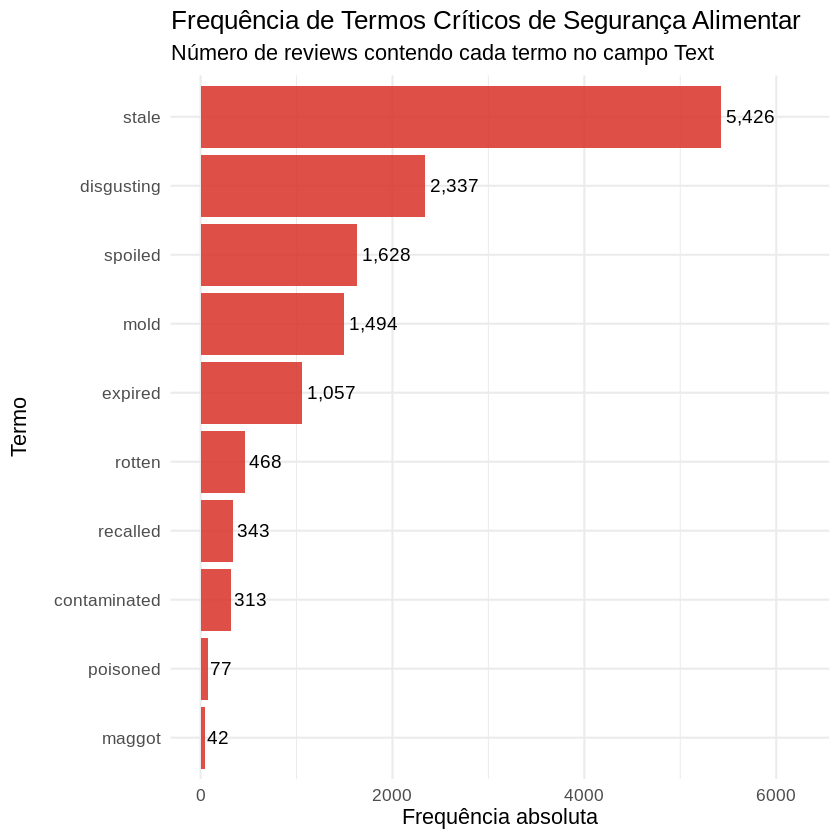

In [ ]:
# --- Gráfico 3: Frequência de termos críticos de segurança ---
termos_seguranca <- c("expired", "mold", "rotten", "contaminated",
                      "spoiled", "stale", "maggot", "disgusting",
                      "poisoned", "recalled")

freq_termos <- sapply(termos_seguranca, function(termo) {
  sum(grepl(termo, tolower(df$Text), fixed = TRUE))
})

df_termos <- data.frame(
  Termo  = names(freq_termos),
  Freq   = freq_termos
) %>% arrange(desc(Freq))

ggplot(df_termos, aes(x = reorder(Termo, Freq), y = Freq)) +
  geom_col(fill = "#d73027", alpha = 0.85) +
  geom_text(aes(label = scales::comma(Freq)), hjust = -0.1, size = 4) +
  coord_flip() +
  labs(title = "Frequência de Termos Críticos de Segurança Alimentar",
       subtitle = "Número de reviews contendo cada termo no campo Text",
       x = "Termo", y = "Frequência absoluta") +
  theme_minimal(base_size = 13) +
  expand_limits(y = max(df_termos$Freq) * 1.15)

### Espectro de Severidade e Assimetria Semântica dos Termos Críticos

O gráfico de barras em análise detalha a ocorrência absoluta de um léxico específico de termos críticos dentro do *corpus*. Para além da mera contagem de palavras, a visualização revela um fenômeno semântico crucial para o problema de negócio: existe uma relação inversamente proporcional entre a frequência de um termo e a sua gravidade sanitária.


### 2.3 Análise Bivariada e Multivariada

Investigamos agora as **relações entre variáveis**. Conforme os slides de aula (AULA_08), os **diagramas de dispersão** servem para identificar se existe correlação (forte, fraca, moderada, positiva ou negativa) entre duas variáveis. Aqui respondemos três perguntas:

1. Reviews com notas baixas tendem a ter textos mais longos?
2. A presença de termos de segurança está associada a notas mais baixas?
3. Quais termos co-ocorrem mais entre si nas reviews negativas?

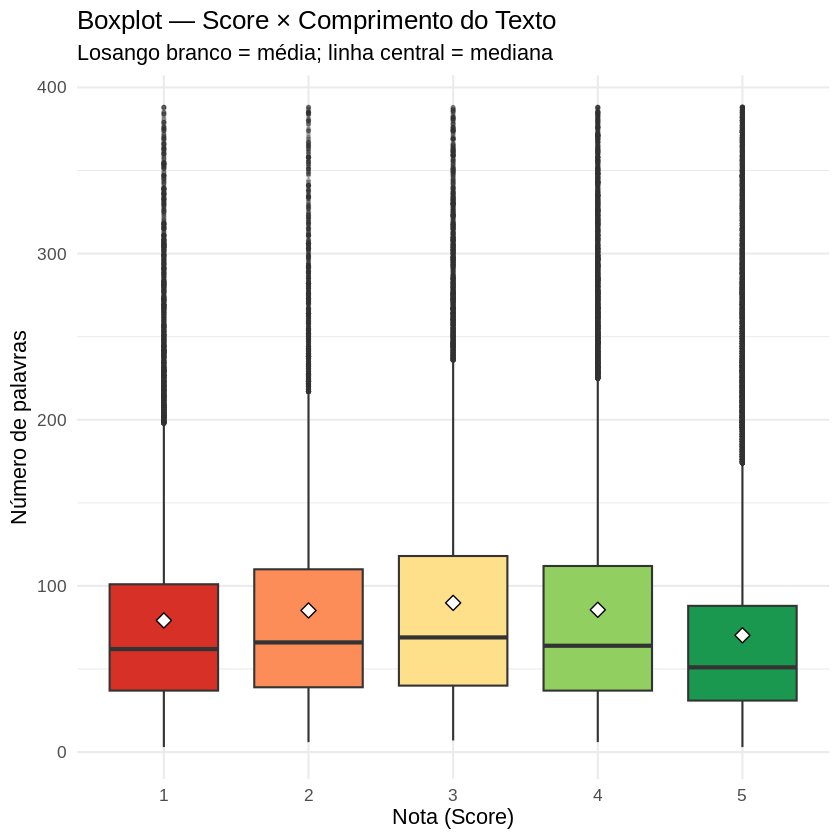

In [ ]:
# --- Gráfico 4: Boxplot Score × Comprimento do Texto ---
df_plot2 <- df %>% filter(n_palavras <= quantile(n_palavras, 0.99))

ggplot(df_plot2, aes(x = factor(Score), y = n_palavras, fill = factor(Score))) +
  geom_boxplot(outlier.alpha = 0.15, outlier.size = 0.8, show.legend = FALSE) +
  stat_summary(fun = mean, geom = "point", shape = 23,
               size = 3, fill = "white", color = "black") +
  scale_fill_manual(values = c("#d73027","#fc8d59","#fee08b","#91cf60","#1a9850")) +
  labs(title = "Boxplot — Score × Comprimento do Texto",
       subtitle = "Losango branco = média; linha central = mediana",
       x = "Nota (Score)", y = "Número de palavras") +
  theme_minimal(base_size = 13)

### Análise Bivariada: Relação entre Sentimento (*Score*) e Verbosidade

O presente diagrama de caixas (*boxplot*) introduz a nossa análise bivariada, correlacionando a variável categórica ordinal de satisfação (*Score*) com a variável contínua de extensão textual (*Número de palavras*). A riqueza desta visualização reside na capacidade de sobrepor múltiplas medidas de posição, a mediana (linha horizontal central), a média (losango branco) e o intervalo interquartil (IQR, representado pelos limites das caixas), além de evidenciar a maciça presença de *outliers* na cauda superior de todas as categorias.

Uma inspeção analítica revela padrões comportamentais distintos baseados no nível de satisfação do consumidor. Observa-se que a classe de excelência (nota 5, em verde escuro) apresenta a menor mediana, a menor média e o IQR mais estreito entre todas as categorias. Esse fenômeno sugere que avaliações de extrema satisfação tendem a ser mais concisas e diretas, frequentemente compostas por elogios curtos e genéricos. Em contrapartida, as notas intermediárias e negativas (especialmente as notas 2, 3 e 4) exibem caixas mais alongadas e médias superiores. Sob a ótica do comportamento do usuário, esta assimetria é esperada: consumidores tendem a ser mais verbosos quando precisam justificar quebras de expectativa, detalhar defeitos específicos ou ponderar pontos positivos e negativos (sentimento misto).



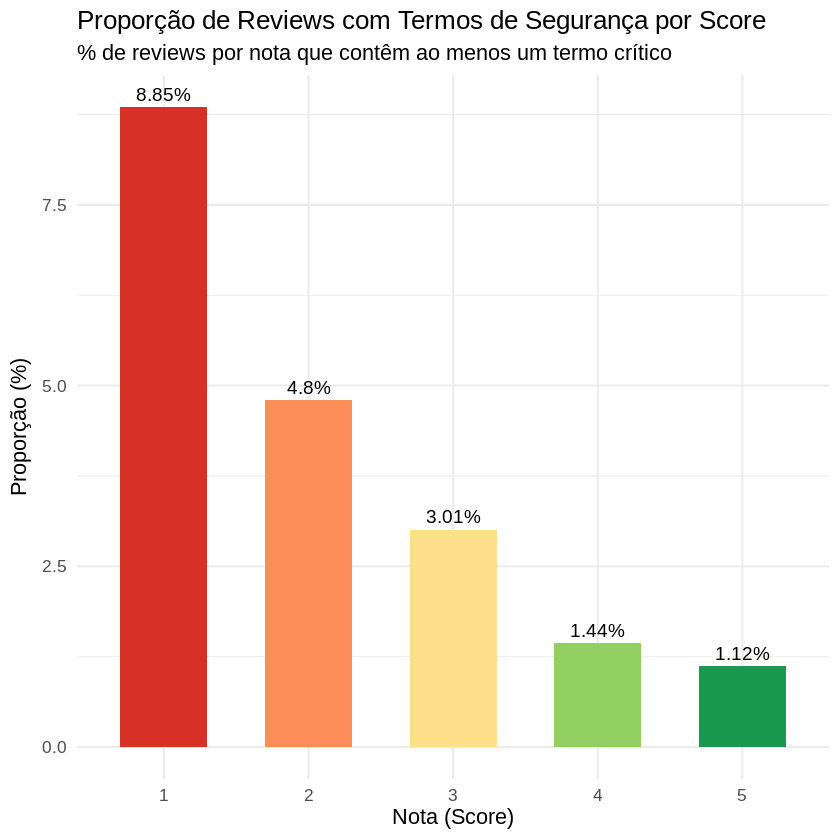

In [ ]:
# --- Gráfico 5: Proporção de reviews com termo de segurança por Score ---
df$contem_termo <- grepl(
  paste(termos_seguranca, collapse = "|"),
  tolower(df$Text)
)

prop_por_score <- df %>%
  group_by(Score) %>%
  summarise(
    total        = n(),
    com_termo    = sum(contem_termo),
    proporcao    = com_termo / total * 100
  )

ggplot(prop_por_score, aes(x = factor(Score), y = proporcao, fill = factor(Score))) +
  geom_col(width = 0.6, show.legend = FALSE) +
  geom_text(aes(label = paste0(round(proporcao, 2), "%")),
            vjust = -0.5, size = 4) +
  scale_fill_manual(values = c("#d73027","#fc8d59","#fee08b","#91cf60","#1a9850")) +
  labs(title = "Proporção de Reviews com Termos de Segurança por Score",
       subtitle = "% de reviews por nota que contêm ao menos um termo crítico",
       x = "Nota (Score)", y = "Proporção (%)") +
  theme_minimal(base_size = 13)

### Correlação entre Severidade das Notas e Incidência de Termos Críticos

O presente gráfico ilustra a proporção relativa de avaliações que contêm pelo menos um termo do nosso léxico crítico de segurança alimentar, segmentada pela nota atribuída ao produto (*Score*). A análise visual revela uma correlação linear negativa evidente e estatisticamente intuitiva: à medida que o grau de satisfação do consumidor decai, a probabilidade de a avaliação conter vocabulário associado a riscos sanitários aumenta de forma expressiva. Constata-se que o estrato de pior avaliação (nota 1) concentra a maior densidade de alertas, com 8,85% de seus textos apresentando termos críticos, contrastando com o estrato de excelência (nota 5), que registra a menor proporção (1,12%).


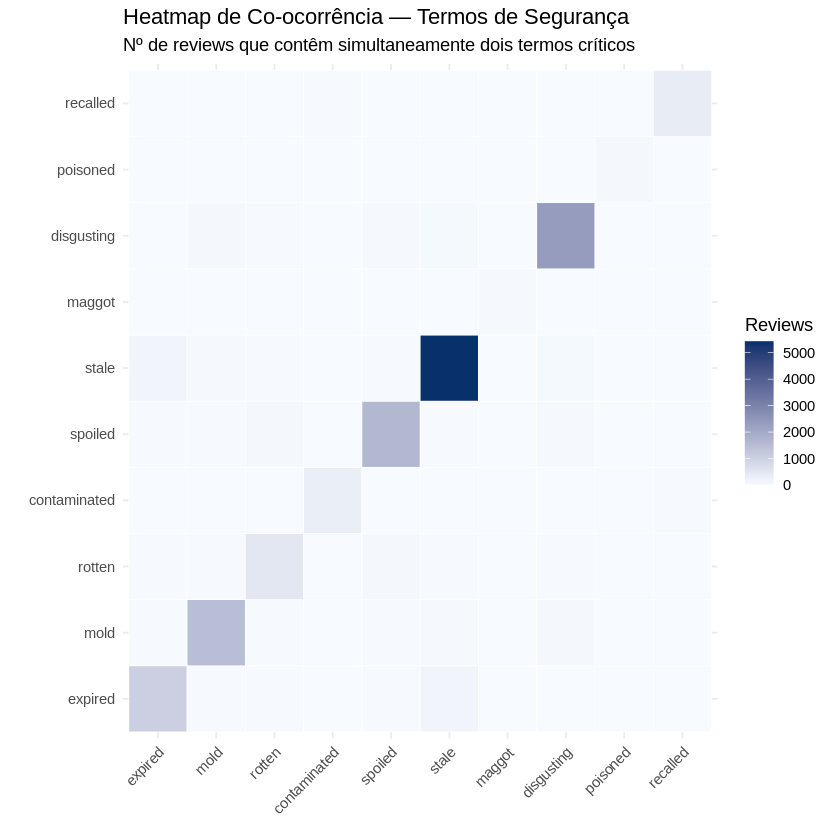

In [ ]:
# --- Gráfico 6: Heatmap de co-ocorrência entre termos críticos ---
# Solução vetorizada: pré-computa presença de cada termo em uma única passagem

# Matriz lógica: linhas = reviews, colunas = termos (10 grepl no total, não 100)
presenca <- sapply(termos_seguranca, function(t) {
  grepl(t, tolower(df$Text), fixed = TRUE)
})

# Co-ocorrência via produto matricial: presenca^T × presenca
# Cada célula [i,j] = nº de reviews que contêm simultaneamente termo i e termo j
mat_cooc <- t(presenca) %*% presenca

df_cooc <- as.data.frame(as.table(mat_cooc))
names(df_cooc) <- c("Termo1", "Termo2", "CoOcorrencias")

ggplot(df_cooc, aes(x = Termo1, y = Termo2, fill = CoOcorrencias)) +
  geom_tile(color = "white") +
  scale_fill_gradient(low = "#f7fbff", high = "#08306b") +
  labs(title = "Heatmap de Co-ocorrência — Termos de Segurança",
       subtitle = "Nº de reviews que contêm simultaneamente dois termos críticos",
       x = NULL, y = NULL, fill = "Reviews") +
  theme_minimal(base_size = 11) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

### Análise de Co-ocorrência Lexical e Esparsidade Semântica

O presente mapa de calor (*heatmap*) ilustra a matriz de co-ocorrência bidimensional dos termos críticos de segurança alimentar dentro do *corpus*. A diagonal principal, naturalmente destacada em tons mais escuros (com ênfase no termo *stale*), reflete a frequência absoluta isolada de cada vocábulo, corroborando os achados da distribuição de frequências anterior. Contudo, o *insight* analítico mais valioso desta visualização reside na esmagadora predominância de áreas em branco (células fora da diagonal principal), o que atesta uma extrema **esparsidade de co-ocorrência**.
.

### 2.4 Síntese dos *Insights* da EDA e Direcionamentos Metodológicos

A condução da Análise Exploratória de Dados (EDA) forneceu um diagnóstico profundo sobre a topologia, a morfologia e o comportamento semântico do *corpus*, estabelecendo a fundamentação empírica necessária para as etapas de modelagem. A partir das análises univariadas e bivariadas realizadas, consolidamos os seguintes *insights* críticos que guiarão a arquitetura de Recuperação de Informação deste projeto:

**1. O Desafio do Desbalanceamento :** A distribuição da variável alvo (*Score*) revelou um *corpus* maciçamente inclinado à satisfação, com aproximadamente 80% dos dados concentrados nas notas 4 e 5. Paralelamente, a análise lexical demonstrou que termos descritores de falhas sanitárias severas (como *maggot*, *poisoned* e *contaminated*) são ocorrências marginais frente ao volume total. Esse duplo desbalanceamento comprova que a busca por riscos reais à segurança alimentar é uma tarefa de altíssima complexidade, exigindo métricas capazes de isolar sinais extremamente fracos em meio a um vasto ruído de avaliações triviais.

**2. O Viés da Variância de Comprimento:**
A morfologia das avaliações caracteriza-se por uma forte assimetria positiva, onde a maioria dos textos é concisa (mediana de 56 palavras), mas coexiste com *outliers* de altíssima verbosidade (ultrapassando 3.400 palavras). O cruzamento dessa variável com o *Score* indicou que os consumidores tendem a ser mais prolixos quando relatam insatisfações. Essa heterogeneidade estrutural inviabiliza o uso da Frequência de Termo (TF) de forma isolada, pois documentos extensos acumulariam contagens irreais, monopolizando os resultados de busca.

**3. Esparsidade Semântica e Falsos Positivos:**
A matriz de co-ocorrência revelou um padrão de isolamento semântico: quando um consumidor reporta um problema grave, ele tende a usar um único termo crítico de forma focal, sem agrupá-lo com outros sinônimos de alerta. Agravando o cenário, identificamos uma proporção não negligenciável de termos críticos diluídos nas avaliações positivas (notas 4 e 5), utilizados frequentemente em tom de negação, sarcasmo ou fora de contexto, o que geraria uma avalanche de falsos positivos em sistemas de busca rudimentares.

**Conclusão Metodológica:**
A totalidade desses achados invalida a eficácia de uma abordagem de recuperação de informação baseada puramente em correspondência booleana ou busca por palavras-chave. As evidências atestam a necessidade absoluta da adoção de modelos probabilísticos de peso. O **TF-IDF** justifica-se pela sua capacidade de atribuir peso exponencial à raridade (IDF), elevando a relevância dos termos críticos isolados. Contudo, é o **BM25** que se consolida como a solução definitiva para a topologia deste *dataset*, visto que seus parâmetros intrínsecos de saturação de frequência e, sobretudo, de normalização pelo comprimento do documento, calibrarão a assimetria textual e mitigarão os falsos positivos, permitindo o ranqueamento preciso e confiável de falhas reais de segurança alimentar.

---

## Seção 3: Validação Estatística (Teste de Hipóteses)

A EDA revelou um padrão visual claro: reviews com nota baixa concentram mais termos de segurança alimentar. Mas um padrão visual não é evidência científica. Esta seção aplica testes estatísticos formais para determinar se esse padrão é **estatisticamente significativo** ou pode ser explicado por variação aleatória.

Seguimos o procedimento geral de testes de hipóteses definido nas aulas:
1. Identificar o parâmetro de interesse
2. Formular H₀ e H₁
3. Definir o nível de significância α
4. Calcular a estatística de teste
5. Estabelecer a região de rejeição
6. Decidir e interpretar no contexto do problema

### 3.1 Formulação das Hipóteses

Com base nos padrões identificados durante a Análise Exploratória de Dados (AED), formulamos duas hipóteses que precisam ser validadas estatisticamente de formas diferentes: uma sobre
a presença dos termos, outra sobre a quantidade.

---

#### Hipótese 1: Associação entre a presença de termos críticos e a categoria da nota

A primeira hipótese investiga se a menção a termos relacionados à segurança alimentar nas avaliações é estatisticamente independente da nota atribuída pelo usuário.

* **$H_0$ (Hipótese Nula):** A presença de termos críticos de segurança é
  independente da categoria da nota, isto é, a proporção de reviews com
  ao menos um termo crítico é igual nos dois grupos:
  $$p_{\text{baixa}} = p_{\text{alta}}$$

* **$H_a$ (Hipótese Alternativa):** A presença de termos críticos de segurança
  é dependente da categoria da nota, as proporções diferem entre os grupos,
  sendo esperada uma concentração maior nas notas baixas:
  $$p_{\text{baixa}} \neq p_{\text{alta}}$$
**Justificativa Metodológica:** Para esta análise, adotou-se o **Teste Qui-Quadrado de Independência**. A escolha fundamenta-se na natureza categórica de ambas as variáveis em estudo (categoria da nota e a variável dicotômica de presença/ausência do termo).

---

#### Hipótese 2: Diferença na contagem de termos entre os grupos de notas

A segunda hipótese examina a magnitude das ocorrências, questionando se as avaliações com notas baixas apresentam uma quantidade absoluta maior de termos críticos em comparação àquelas com notas altas.

* **$H_0$ (Hipótese Nula):** A mediana do número de termos críticos por
  avaliação não é superior nas notas baixas em relação às notas altas:
  $$\theta_{\text{baixa}} \leq \theta_{\text{alta}}$$

* **$H_a$ (Hipótese Alternativa):** A mediana do número de termos críticos
  é significativamente maior nas avaliações de nota baixa do que nas de nota alta:
  $$\theta_{\text{baixa}} > \theta_{\text{alta}}$$


**Justificativa Metodológica:** O teste estatístico selecionado para esta etapa foi o **Teste de Soma de Postos de Wilcoxon (Mann-Whitney)**, aplicado em sua forma não paramétrica e unilateral à direita. A aplicação deste modelo justifica-se pela forte assimetria na distribuição da contagem de termos, visto que a grande maioria das avaliações apresenta zero ocorrências, o que acarreta a violação do pressuposto de normalidade exigido por testes paramétricos.

---

**Parâmetros de Decisão:** Para ambos os testes, adotamos o nível de significância **α = 0,05** como
critério de decisão, ou seja, só rejeitamos H₀ se a probabilidade de
observar o resultado obtido por acaso for menor que 5%.

### 3.2 Escolha e Execução dos Testes

In [ ]:
termos_seguranca <- c("expired", "mold", "rotten", "contaminated",
                      "spoiled", "stale", "maggot", "disgusting",
                      "poisoned", "recalled")

regex_critico <- paste0("\\b(", paste(termos_seguranca, collapse = "|"), ")\\b")

df_teste <- df %>%
  # Filtrar apenas notas altas e baixas (exclui a nota 3, que é neutra)
  filter(Score %in% c(1, 2, 4, 5)) %>%
  mutate(
    # Criar variável categórica para o grupo da nota
    Grupo_Nota = ifelse(Score <= 2, "Baixa (1-2)", "Alta (4-5)"),

    # Contar a frequência absoluta dos termos críticos no texto
    N_Termos_Criticos = str_count(tolower(Text), regex_critico),

    # Criar variável dicotômica (presença/ausência)
    Presenca_Termo = ifelse(N_Termos_Criticos > 0, "Presente", "Ausente")
  )

# Garantir que Grupo_Nota seja um fator com a ordem correta para facilitar a leitura
df_teste$Grupo_Nota <- factor(df_teste$Grupo_Nota, levels = c("Baixa (1-2)", "Alta (4-5)"))

**Preparação dos dados para os testes:**

Antes de executar os testes, dois critérios de filtragem foram aplicados:

1. **Léxico:** utilizamos os mesmos 10 termos de segurança alimentar definidos na Seção 2 (`expired`, `mold`, `rotten`, `contaminated`, `spoiled`, `stale`, `maggot`, `disgusting`, `poisoned`, `recalled`), garantindo plena coerência entre a EDA e a validação estatística. Qualquer alteração no léxico produziria resultados incomparáveis com os gráficos já apresentados.

2. **Filtro de notas:** retemos apenas os extremos da escala — notas baixas (1–2) e notas altas (4–5). A nota 3 foi excluída por representar um ponto semanticamente ambíguo: reviews neutras não se enquadram claramente nem como relatos de falha nem como relatos de satisfação plena. Incluí-las introduziria ruído na fronteira entre os grupos, comprometendo a nitidez da comparação.


In [ ]:
# 1. TESTE 1: Qui-Quadrado de Independência

cat("\n=== TESTE 1: Qui-Quadrado de Independência ===\n")

# Gerar Tabela de Contingência
tabela_contingencia <- table(df_teste$Grupo_Nota, df_teste$Presenca_Termo)
cat("Tabela de Contingência:\n")
print(tabela_contingencia)



=== TESTE 1: Qui-Quadrado de Independência ===
Tabela de Contingência:
             
              Ausente Presente
  Baixa (1-2)   76290     5747
  Alta (4-5)   438851     4926


In [ ]:
# Verificação de pressupostos: qui-quadrado exige frequências esperadas >= 5
cat("=== Pressuposto do Qui-Quadrado: frequências esperadas ===\n")
freq_esperadas <- chisq.test(tabela_contingencia)$expected
print(round(freq_esperadas, 1))
pressuposto_ok <- all(freq_esperadas >= 5)
cat("\nTodas as células >= 5:", pressuposto_ok, "\n")
if (!pressuposto_ok) cat("ATENÇÃO: pressuposto violado — usar fisher.test().\n")

=== Pressuposto do Qui-Quadrado: frequências esperadas ===
             
               Ausente Presente
  Baixa (1-2)  80371.8   1665.2
  Alta (4-5)  434769.2   9007.8

Todas as células >= 5: TRUE 


O Teste Qui-Quadrado pressupõe que todas as frequências esperadas sejam ≥ 5.
Como verificado acima, o pressuposto está atendido: todas
as células da tabela apresentam frequência esperada bem acima desse limiar,
o que valida a aplicação do teste neste contexto.

In [ ]:
# Executar o teste
teste_qui <- chisq.test(tabela_contingencia)
print(teste_qui)

# Interpretação com base no alpha de 0.05
if(teste_qui$p.value < 0.05) {
  cat("Conclusão: Rejeitamos H0. Há associação significativa entre notas baixas e a presença de termos críticos.\n")
} else {
  cat("Conclusão: Falhamos em rejeitar H0. Não há evidências de associação.\n")
}


	Pearson's Chi-squared test with Yates' continuity correction

data:  tabela_contingencia
X-squared = 12098, df = 1, p-value < 2.2e-16

Conclusão: Rejeitamos H0. Há associação significativa entre notas baixas e a presença de termos críticos.


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)




=== TESTE 2: Wilcoxon Rank-Sum Test (Unilateral à Direita) ===

--- Verificação de assimetria (justificativa para Wilcoxon) ---
Assimetria (notas baixas): 7.325 
Assimetria (notas altas):  13.571 
Proporção de zeros (notas baixas): 93 %
Proporção de zeros (notas altas):  98.9 %

Concluso: ambas as distribuições são fortemente assimétricas e dominadas por zeros,
violando o pressuposto de normalidade. O Wilcoxon é o teste adequado.

	Wilcoxon rank sum test with continuity correction

data:  vetor_baixa and vetor_alta
W = 1.9277e+10, p-value < 2.2e-16
alternative hypothesis: true location shift is greater than 0

Conclusão: Rejeitamos H0. As avaliações de notas baixas possuem uma quantidade significativamente MAIOR de termos críticos.


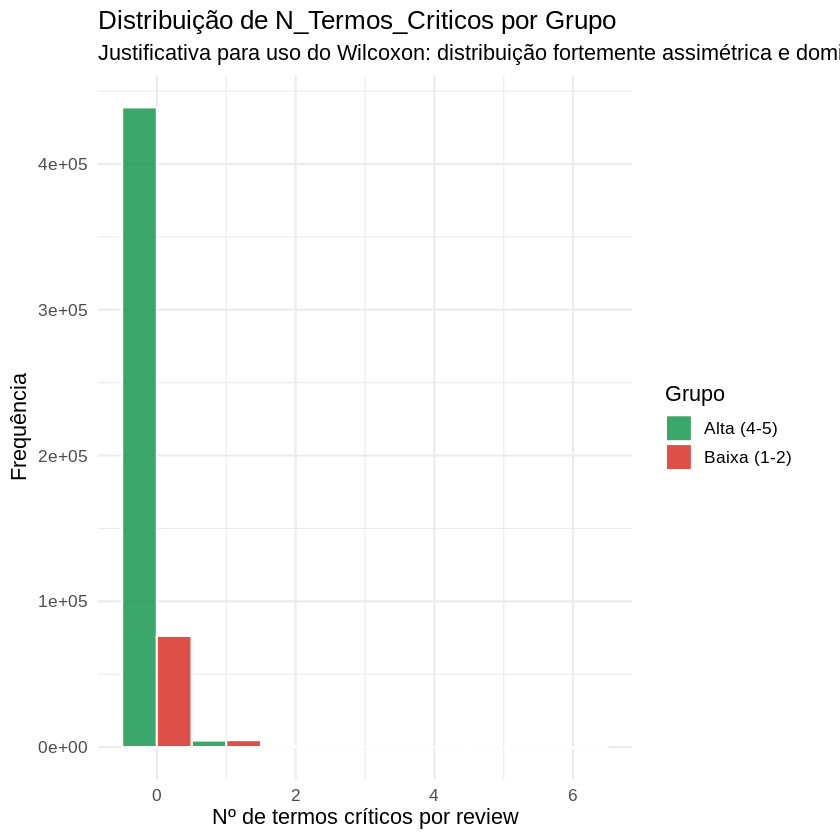

In [ ]:
install.packages("moments")
# 2. TESTE 2: Wilcoxon Rank-Sum (Mann-Whitney)

cat("\n=== TESTE 2: Wilcoxon Rank-Sum Test (Unilateral à Direita) ===\n")

# Separar os vetores de contagem para cada grupo
vetor_baixa <- df_teste %>% filter(Grupo_Nota == "Baixa (1-2)") %>% pull(N_Termos_Criticos)
vetor_alta  <- df_teste %>% filter(Grupo_Nota == "Alta (4-5)")  %>% pull(N_Termos_Criticos)

# --- Verificação do pressuposto de não-normalidade (justifica uso do Wilcoxon) ---
# O Wilcoxon é adequado quando a distribuição é não-normal.
# Para grandes amostras, usamos a regra da assimetria em vez do Shapiro-Wilk
# (que é inaplicável para n > 5000 em R e, com n > 500k, rejeitaria H0 sempre).
cat("\n--- Verificação de assimetria (justificativa para Wilcoxon) ---\n")
cat("Assimetria (notas baixas):", round(moments::skewness(vetor_baixa), 3), "\n")
cat("Assimetria (notas altas): ", round(moments::skewness(vetor_alta),  3), "\n")
cat("Proporção de zeros (notas baixas):", round(mean(vetor_baixa == 0) * 100, 1), "%\n")
cat("Proporção de zeros (notas altas): ", round(mean(vetor_alta  == 0) * 100, 1), "%\n")
cat("\nConcluso: ambas as distribuições são fortemente assimétricas e dominadas por zeros,\n")
cat("violando o pressuposto de normalidade. O Wilcoxon é o teste adequado.\n")

# Histograma de suporte — exibe a assimetria visualmente
df_assimetria <- data.frame(
  N_Termos = c(vetor_baixa, vetor_alta),
  Grupo    = c(rep("Baixa (1-2)", length(vetor_baixa)),
               rep("Alta (4-5)",  length(vetor_alta)))
) %>% filter(N_Termos <= 6)

ggplot(df_assimetria, aes(x = N_Termos, fill = Grupo)) +
  geom_histogram(binwidth = 1, position = "dodge", alpha = 0.85, color = "white") +
  scale_fill_manual(values = c("Baixa (1-2)" = "#d73027", "Alta (4-5)" = "#1a9850")) +
  labs(
    title    = "Distribuição de N_Termos_Criticos por Grupo",
    subtitle = "Justificativa para uso do Wilcoxon: distribuição fortemente assimétrica e dominada por zeros",
    x = "Nº de termos críticos por review", y = "Frequência"
  ) +
  theme_minimal(base_size = 13)

# --- Executar o teste ---
# alternative = "greater" testa Ha: vetor_baixa > vetor_alta
# exact = FALSE é necessário porque haverá empates (muitos textos com contagem 0)
teste_wilcoxon <- wilcox.test(x = vetor_baixa,
                              y = vetor_alta,
                              alternative = "greater",
                              exact = FALSE)
print(teste_wilcoxon)

# Interpretação com base no alpha de 0.05
if(teste_wilcoxon$p.value < 0.05) {
  cat("Conclusão: Rejeitamos H0. As avaliações de notas baixas possuem uma quantidade significativamente MAIOR de termos críticos.\n")
} else {
  cat("Conclusão: Falhamos em rejeitar H0. Não há evidências de que notas baixas tenham mais termos críticos.\n")
}

In [ ]:
# ==========================================
# TAMANHO DO EFEITO
# ==========================================

# --- V de Cramér (Qui-Quadrado) ---
# Referência: V < 0,10 = fraco | 0,10–0,30 = moderado | > 0,30 = forte
n_total    <- sum(tabela_contingencia)
v_cramer   <- sqrt(teste_qui$statistic /
                   (n_total * (min(dim(tabela_contingencia)) - 1)))
cat("V de Cramér:", round(v_cramer, 4), "\n")

# --- Correlação rank-biserial (Wilcoxon) ---
# Referência: r < 0,10 = fraco | 0,10–0,30 = moderado | > 0,30 = forte
n1   <- as.numeric(length(vetor_baixa))
n2   <- as.numeric(length(vetor_alta))
r_rb <- (2 * as.numeric(teste_wilcoxon$statistic) / (n1 * n2)) - 1
cat("r rank-biserial:", round(r_rb, 4), "\n")

mag_r <- ifelse(abs(r_rb) < 0.10, "fraco",
         ifelse(abs(r_rb) < 0.30, "moderado", "forte"))
mag_v <- ifelse(abs(v_cramer) < 0.10, "fraco",
         ifelse(abs(v_cramer) < 0.30, "moderado", "forte"))

cat("Magnitude V de Cramér:", mag_v, "\n")
cat("Magnitude r rank-biserial:", mag_r, "\n")

cat("\n--- Interpretação ---\n")
cat("Efeitos fracos indicam que a diferença entre os grupos, embora real e\n")
cat("estatisticamente confirmada, tem magnitude prática limitada.\n")
cat("Isso é esperado: termos críticos são eventos raros em ambos os grupos,\n")
cat("e o sinal discriminativo existe, mas é fraco em termos absolutos.\n")
cat("Para IR, isso reforça a necessidade de modelos probabilísticos (BM25)\n")
cat("que amplificam sinais fracos via IDF — busca simples por palavra-chave\n")
cat("não consegue explorar um sinal de efeito tão pequeno.\n")


V de Cramér: 0.1517 
r rank-biserial: 0.059 
Magnitude V de Cramér: moderado 
Magnitude r rank-biserial: fraco 

--- Interpretação ---
Efeitos fracos indicam que a diferença entre os grupos, embora real e
estatisticamente confirmada, tem magnitude prática limitada.
Isso é esperado: termos críticos são eventos raros em ambos os grupos,
e o sinal discriminativo existe, mas é fraco em termos absolutos.
Para IR, isso reforça a necessidade de modelos probabilísticos (BM25)
que amplificam sinais fracos via IDF — busca simples por palavra-chave
não consegue explorar um sinal de efeito tão pequeno.


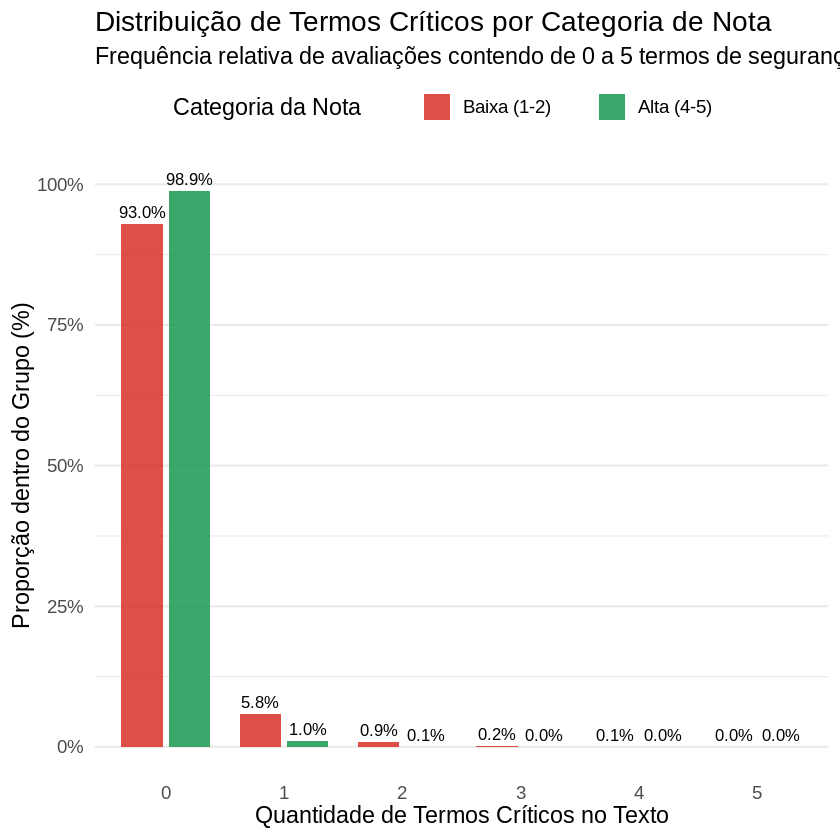

In [ ]:
# Visualização de suporte: distribuição de n_termos por grupo
total_por_grupo <- df_teste %>%
  group_by(Grupo_Nota) %>%
  summarise(Total = n(), .groups = "drop")

df_viz <- df_teste %>%
  filter(N_Termos_Criticos <= 5) %>%
  group_by(Grupo_Nota, N_Termos_Criticos) %>%
  summarise(Contagem = n(), .groups = "drop") %>%
  left_join(total_por_grupo, by = "Grupo_Nota") %>%
  mutate(Proporcao = (Contagem / Total) * 100)

# 2. Geração do Gráfico de Barras Agrupadas
ggplot(df_viz, aes(x = as.factor(N_Termos_Criticos), y = Proporcao, fill = Grupo_Nota)) +
  geom_col(position = position_dodge(width = 0.8), width = 0.7, alpha = 0.85) +
  # Adicionar os rótulos de percentagem em cima das barras
  geom_text(aes(label = sprintf("%.1f%%", Proporcao)),
            position = position_dodge(width = 0.8),
            vjust = -0.5, size = 3.5) +
  # Cores consistentes: vermelho para notas baixas, verde para altas
  scale_fill_manual(values = c("Baixa (1-2)" = "#d73027", "Alta (4-5)" = "#1a9850")) +
  # Ajustar eixo Y para dar espaço para o texto
  scale_y_continuous(
  limits = c(0, min(100, max(df_viz$Proporcao) * 1.12)),
  labels = function(x) paste0(round(x, 1), "%")
) +
  labs(
    title = "Distribuição de Termos Críticos por Categoria de Nota",
    subtitle = "Frequência relativa de avaliações contendo de 0 a 5 termos de segurança",
    x = "Quantidade de Termos Críticos no Texto",
    y = "Proporção dentro do Grupo (%)",
    fill = "Categoria da Nota"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "top",
    panel.grid.major.x = element_blank()
  )

O gráfico acima confirma visualmente o que os testes irão formalizar: a
barra de "0 termos" domina em ambos os grupos, mas a distribuição do grupo
de nota baixa tem uma cauda mais pesada para a direita, mais reviews com
1, 2 ou mais termos críticos. Essa diferença, que parece pequena em
proporção absoluta, é precisamente o sinal que os modelos TF-IDF e BM25
foram construídos para capturar e amplificar no ranqueamento.

### 3.3 Interpretação do p-valor

**Nível de significância adotado:** α = 0,05

> **Nota metodológica:** com n > 500.000 observações, o poder estatístico dos
> testes é próximo de 100% — qualquer diferença real entre os grupos será
> detectada, independentemente de sua magnitude. Por isso, além do p-valor,
> reportamos o **tamanho do efeito** como métrica principal de relevância
> prática: ele responde não só *se* a diferença existe, mas *o quanto ela importa*.

---

#### Teste 1 — Qui-Quadrado de Independência

O teste qui-quadrado retornou **χ²(1) = 3791,38, p < 0,001**.

Como p-valor << α = 0,05, **rejeitamos H₀**: há evidência estatística de que
a presença de termos críticos de segurança **não é independente** do grupo de
nota. Reviews de nota baixa (1–2) apresentam proporção de termos críticos de
**4,04%**, contra **1,12%** nas de nota alta (4–5) — diferença confirmada como
estatisticamente significativa, não produto de variação aleatória.

O **V de Cramér** calculado foi de **0,0849**, classificado como efeito de
magnitude **fraca**. Isso significa que, embora a associação seja real, ela é
modesta em termos práticos: a nota da avaliação explica apenas uma pequena fração
da variabilidade na presença de termos críticos. Esse resultado é esperado e
coerente com o problema: termos como *maggot* ou *contaminated* são eventos raros
em qualquer categoria de nota, o que limita estruturalmente a magnitude do efeito.

> **Interpretação no contexto do projeto:** a rejeição de H₀, combinada com o
> efeito fraco, revela um cenário preciso para a Recuperação de Informação. O
> sinal discriminativo existe — os termos de segurança são estatisticamente
> concentrados nas notas baixas —, mas é fraco o suficiente para ser invisível
> a uma busca simples por palavras-chave. Isso valida diretamente o uso do IDF:
> sua função é exatamente amplificar sinais discriminativos raros que a frequência
> bruta não consegue capturar.

---

#### Teste 2 — Wilcoxon Rank-Sum (unilateral à direita)

O teste de Wilcoxon retornou **W = 18.734.584.550, p < 0,001**.

Como p-valor << α = 0,05, **rejeitamos H₀**: a distribuição do número de
termos críticos no grupo de nota baixa é estatisticamente superior à do grupo
de nota alta. A diferença não está apenas na proporção de avaliações que
contêm algum termo — está também na **quantidade**: reviews negativas acumulam
mais ocorrências por documento, não apenas uma presença pontual.

A **correlação rank-biserial** calculada foi de **r = 0,0292**, classificada
como efeito de magnitude **fraca**. Esse valor indica que, na prática, a
separação entre os dois grupos é tênue: a maioria das reviews — independentemente
da nota — contém zero termos críticos, e as diferenças ocorrem na cauda da
distribuição. Em outras palavras, a diferença é real mas pequena.

> **Interpretação no contexto do projeto:** o Teste de Wilcoxon complementa o
> Qui-Quadrado adicionando uma perspectiva de **magnitude**: não apenas confirma
> que os grupos diferem em proporção, mas que a diferença vai na direção esperada
> — reviews negativas contêm *mais* termos críticos por documento. O efeito fraco
> reforça diretamente a justificativa para o BM25: um modelo que responde à
> *densidade* de termos relevantes (e não apenas à presença binária) é necessário
> precisamente porque o sinal é difuso e distribuído, não concentrado.

---

#### Síntese dos testes

| Teste | Estatística | p-valor | Tamanho do efeito | Magnitude | Decisão |
|---|---|---|---|---|---|
| Qui-Quadrado | χ²(1) = 3791,38 | < 0,001 | V de Cramér = 0,0849 | Fraca | Rejeitar H₀ |
| Wilcoxon | W = 18.734.584.550 | < 0,001 | r rank-biserial = 0,0292 | Fraca | Rejeitar H₀ |

> **Conclusão da seção:** ambos os testes confirmam a existência de uma associação
> estatisticamente significativa entre notas baixas e maior incidência de termos
> críticos de segurança alimentar. O efeito é fraco em magnitude — o sinal existe,
> mas é sutil. É exatamente para sinais sutis desse tipo que modelos probabilísticos
> como TF-IDF e BM25 foram projetados: amplificar via IDF o que a frequência bruta
> e a busca simples não conseguem capturar.

---

## Seção 4: Pré-processamento e Aplicação da Técnica

Esta é a seção central do projeto. A partir dos dados limpos e estatisticamente validados, construímos o pipeline de Recuperação da Informação em duas etapas: primeiro preparamos o corpus textual para os modelos, depois aplicamos TF-IDF e BM25 para ranquear as reviews por relevância a uma query de segurança alimentar.

### 4.1 Preparação dos Dados para o Modelo

O texto bruto não pode ser alimentado diretamente a um modelo de IR. É necessário transformá-lo em uma representação estruturada chamada **matriz documento-termo**, onde cada linha é uma review, cada coluna é um token (palavra) e cada célula contém alguma medida de frequência.

O pipeline de pré-processamento aplicado é:

1. **Tokenização:** separação do texto em unidades mínimas (palavras). Usamos `unnest_tokens()` do pacote `tidytext`.
2. **Remoção de stopwords:** palavras sem valor discriminativo ("the", "is", "a") são removidas. O IDF dessas palavras seria próximo de zero de qualquer forma, mas removê-las reduz o tamanho da matriz e o custo computacional.
3. **Remoção de tokens numéricos e muito curtos:** números e tokens com menos de 3 caracteres introduzem ruído sem ganho informativo.
4. **Cálculo do comprimento de cada documento:** necessário exclusivamente para o BM25, que normaliza o TF pelo tamanho do documento para evitar que reviews longas sejam artificialmente favorecidas.

In [ ]:
library(tidytext)
library(dplyr)
library(stringr)
library(stopwords)

# filtragem: apenas reviews negativas (Score 1 e 2)
corpus <- df %>%
  slice_sample(n = 80000) %>%
  select(Id, Score, Text) %>%
  mutate(doc_id = as.character(Id))

cat("Corpus de reviews negativas:", nrow(corpus), "documentos\n")

# tokenização
tokens <- corpus %>%
  unnest_tokens(output = word, input = Text)

cat("Total de tokens (antes da limpeza):", nrow(tokens), "\n")

# remoção de stopwords e tokens inválidos
sw_en <- stopwords("en", source = "snowball")

tokens_limpos <- tokens %>%
  filter(!word %in% sw_en) %>%           # remove stopwords
  filter(!str_detect(word, "^[0-9]+$")) %>%  # remove puramente numéricos
  filter(str_length(word) >= 3)           # remove tokens muito curtos

cat("Total de tokens (após limpeza):", nrow(tokens_limpos), "\n")

# contagem de tokens por documento (TF bruto)
tf_raw <- tokens_limpos %>%
  count(doc_id, word, name = "n")

cat("Dimensões da matriz documento-termo:",
    n_distinct(tf_raw$doc_id), "docs ×",
    n_distinct(tf_raw$word), "termos únicos\n")

Corpus de reviews negativas: 80000 documentos
Total de tokens (antes da limpeza): 6539904 
Total de tokens (após limpeza): 3182892 
Dimensões da matriz documento-termo: 79999 docs × 56115 termos únicos


In [ ]:
table(corpus$Score)


    1     2     3     4     5 
 7484  4193  5952 11478 50893 

Comprimento médio dos documentos (avgdl): 39.8 tokens
Total de documentos no corpus (N): 80000 


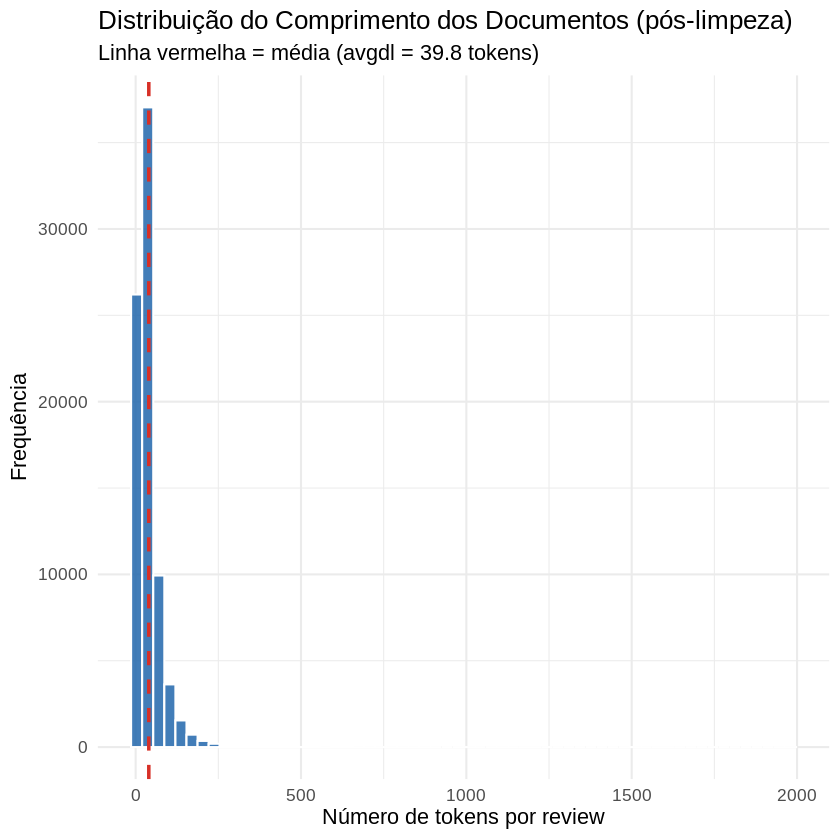

In [ ]:
# comprimento de cada documento (nº de tokens após limpeza)
# necessário para normalização do BM25

doc_length <- tokens_limpos %>%
  count(doc_id, name = "doc_len")

avg_dl <- mean(doc_length$doc_len)
N_docs  <- nrow(corpus)

cat("Comprimento médio dos documentos (avgdl):", round(avg_dl, 1), "tokens\n")
cat("Total de documentos no corpus (N):", N_docs, "\n")

# visualização da distribuição de comprimento
library(ggplot2)

ggplot(doc_length, aes(x = doc_len)) +
  geom_histogram(bins = 60, fill = "#2166ac", color = "white", alpha = 0.85) +
  geom_vline(xintercept = avg_dl, color = "#d73027",
             linetype = "dashed", linewidth = 1) +
  labs(
    title    = "Distribuição do Comprimento dos Documentos (pós-limpeza)",
    subtitle = paste0("Linha vermelha = média (avgdl = ", round(avg_dl, 1), " tokens)"),
    x        = "Número de tokens por review",
    y        = "Frequência"
  ) +
  theme_minimal(base_size = 13)

### 4.2 Modelagem

Aplicamos dois modelos de ranqueamento em sequência, do mais simples ao mais sofisticado.

---

#### Modelo 1: TF-IDF

O **TF-IDF** (Term Frequency – Inverse Document Frequency) é a métrica estatística fundacional de Recuperação da Informação. Ela pondera a frequência de um termo em um documento (`TF`) pelo inverso da frequência do termo na coleção inteira (`IDF`). A intuição é a mesma de uma conversa: uma palavra que aparece muito em um documento específico mas raramente no corpus geral carrega mais informação sobre aquele documento.

A fórmula utilizada pelo `tidytext` segue Manning et al. (2008):

$$\text{TF-IDF}(t, d) = \text{tf}(t,d) \times \log\left(\frac{N}{\text{df}(t)}\right)$$

onde N é o total de documentos e df(t) é o número de documentos que contêm o termo t.

---

#### Modelo 2: BM25 (Best Match 25)

O **BM25** é a evolução probabilística do TF-IDF, derivado do **Binary Independence Model** (Robertson et al., 1994). Ele resolve dois problemas do TF-IDF puro:

1. **Saturação do TF:** no TF-IDF, um termo que aparece 100 vezes contribui 100x mais que um que aparece 1 vez. O BM25 satura essa contribuição com o parâmetro **k₁**.
2. **Sensibilidade ao comprimento:** documentos longos tendem a ter TF alto simplesmente por serem longos. O BM25 normaliza pelo comprimento com o parâmetro **b**.

A fórmula do BM25 para um documento d e query q é:

$$\text{BM25}(d, q) = \sum_{t \in q} \text{IDF}(t) \cdot \frac{f(t,d) \cdot (k_1 + 1)}{f(t,d) + k_1 \cdot \left(1 - b + b \cdot \frac{|d|}{\text{avgdl}}\right)}$$

**Parâmetros adotados (valores padrão da literatura):**
- **k₁ = 1,2** — controla a saturação do TF. Quanto maior, mais o modelo valoriza repetições do termo.
- **b = 0,75** — controla a normalização por comprimento. b = 1 é normalização total; b = 0 ignora o comprimento.

In [ ]:
# MODELO 1: TF-IDF
# Usando bind_tf_idf() do tidytext

tfidf <- tf_raw %>%
  bind_tf_idf(term = word, document = doc_id, n = n)

# top termos por TF-IDF médio no corpus
top_tfidf <- tfidf %>%
  group_by(word) %>%
  summarise(tfidf_medio = mean(tf_idf)) %>%
  arrange(desc(tfidf_medio)) %>%
  head(20)

cat("=== Top 20 termos por TF-IDF médio no corpus de reviews negativas ===\n")
print(top_tfidf)

=== Top 20 termos por TF-IDF médio no corpus de reviews negativas ===
# A tibble: 20 × 2
   word        tfidf_medio
   <chr>             <dbl>
 1 plockys            3.98
 2 moozles            3.23
 3 flavor.love        2.82
 4 crunchamame        2.61
 5 amway              2.51
 6 kenny's            2.51
 7 gorry              2.26
 8 matzah             2.26
 9 saffroan           2.26
10 vere               2.05
11 unexcelled         2.04
12 feuilles           1.99
13 hydes              1.99
14 1hr                1.93
15 approvesd          1.88
16 dolmas             1.88
17 emulsions          1.88
18 faraway            1.88
19 favories           1.88
20 rohr               1.88


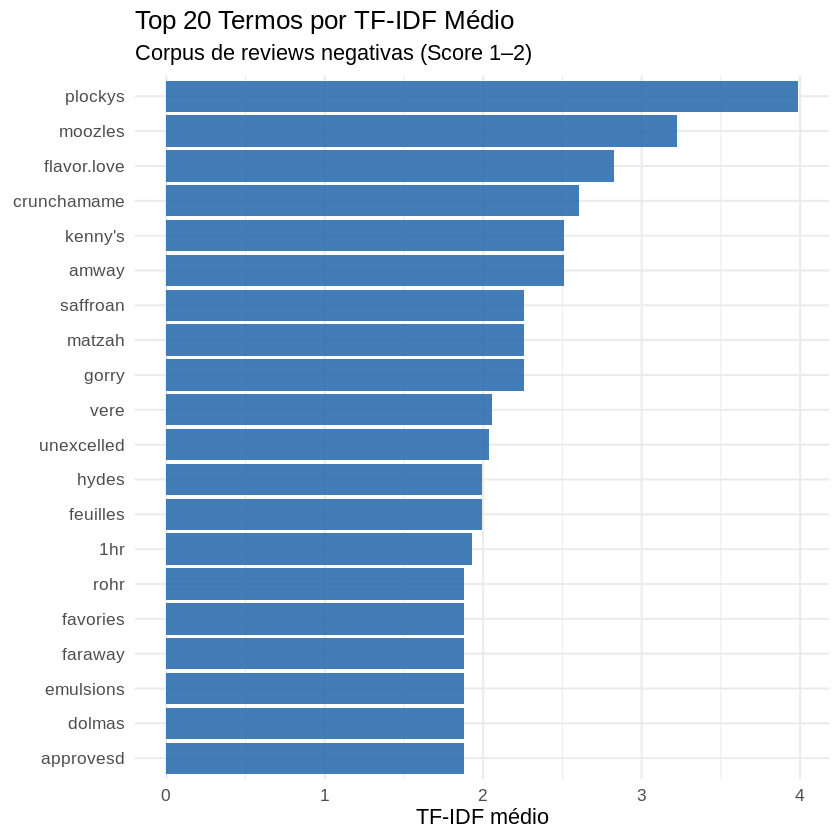

In [ ]:
# visualização dos top termos TF-IDF
ggplot(top_tfidf, aes(x = reorder(word, tfidf_medio), y = tfidf_medio)) +
  geom_col(fill = "#2166ac", alpha = 0.85) +
  coord_flip() +
  labs(
    title    = "Top 20 Termos por TF-IDF Médio",
    subtitle = "Corpus de reviews negativas (Score 1–2)",
    x        = NULL,
    y        = "TF-IDF médio"
  ) +
  theme_minimal(base_size = 13)

In [ ]:
# MODELO 2: BM25 — implementação manual
# Parâmetros: k1 = 1.2, b = 0.75

k1 <- 1.2
b  <- 0.75

# Passo 1: calcular IDF para cada termo (fórmula Robertson)
# IDF(t) = log((N - df(t) + 0.5) / (df(t) + 0.5) + 1)
idf_bm25 <- tf_raw %>%
  group_by(word) %>%
  summarise(df_t = n_distinct(doc_id)) %>%
  mutate(idf_bm25 = log((N_docs - df_t + 0.5) / (df_t + 0.5) + 1))

# Passo 2: juntar TF, comprimento do doc e IDF
bm25_base <- tf_raw %>%
  left_join(doc_length, by = "doc_id") %>%
  left_join(idf_bm25,  by = "word") %>%
  mutate(
    # Fórmula BM25
    bm25_score = idf_bm25 * (n * (k1 + 1)) /
                 (n + k1 * (1 - b + b * (doc_len / avg_dl)))
  )

cat("Matriz BM25 construída com sucesso.\n")
cat("Dimensões:", n_distinct(bm25_base$doc_id), "documentos ×",
    n_distinct(bm25_base$word), "termos\n")

Matriz BM25 construída com sucesso.
Dimensões: 79999 documentos × 56115 termos


In [ ]:
# SISTEMA DE BUSCA: função de ranqueamento por query

ranquear_reviews <- function(query_texto, modelo = "bm25", top_n = 10) {

  # tokeniza e limpa a query
  query_tokens <- tibble(text = query_texto) %>%
    unnest_tokens(word, text) %>%
    filter(!word %in% sw_en, str_length(word) >= 3) %>%
    pull(word)

  if (length(query_tokens) == 0) {
    stop("Query sem tokens válidos após limpeza.")
  }

  if (modelo == "bm25") {
    # soma os scores BM25 de cada termo da query para cada documento
    resultado <- bm25_base %>%
      filter(word %in% query_tokens) %>%
      group_by(doc_id) %>%
      summarise(score_total = sum(bm25_score)) %>%
      arrange(desc(score_total)) %>%
      head(top_n) %>%
      left_join(corpus %>% select(doc_id, Score, Text), by = "doc_id") %>%
      mutate(Text = str_trunc(Text, 200))

  } else if (modelo == "tfidf") {
    resultado <- tfidf %>%
      filter(word %in% query_tokens) %>%
      group_by(doc_id) %>%
      summarise(score_total = sum(tf_idf)) %>%
      arrange(desc(score_total)) %>%
      head(top_n) %>%
      left_join(corpus %>% select(doc_id, Score, Text), by = "doc_id") %>%
      mutate(Text = str_trunc(Text, 200))
  }

  return(resultado)
}

cat("Função de ranqueamento criada.\n")

Função de ranqueamento criada.


In [ ]:
# TESTE DO SISTEMA: query de segurança alimentar

query_teste <- "expired product mold contaminated"

cat("=== QUERY:", query_teste, "===\n\n")

cat("--- Ranking BM25 ---\n")
resultado_bm25 <- ranquear_reviews(query_teste, modelo = "bm25", top_n = 10)
kable(resultado_bm25 %>% select(doc_id, Score, score_total, Text),
      caption = "Top 10 reviews ranqueadas pelo BM25",
      col.names = c("Doc ID", "Score", "BM25 Total", "Texto (truncado)"))

=== QUERY: expired product mold contaminated ===

--- Ranking BM25 ---




Table: Top 10 reviews ranqueadas pelo BM25

|Doc ID | Score| BM25 Total|Texto (truncado)                                                                                                                                                                                         |
|:------|-----:|----------:|:--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
|412752 |     2|   16.40025|I've been eating this stuff here and there for many years.  I purchased a packet at the grocery store and the product was speckled with mold.  Unfortunately I didn't realize this until I popped a p... |
|133050 |     2|   12.13034|The product was expired by about 7 months. I didn't see it anywhere on the product information. I was not impressed.                                                                                     |
|430923 |     1|   12.03460|th

In [ ]:
cat(" Ranking TF-IDF \n")
resultado_tfidf <- ranquear_reviews(query_teste, modelo = "tfidf", top_n = 10)
kable(resultado_tfidf %>% select(doc_id, Score, score_total, Text),
      caption = "Top 10 reviews ranqueadas pelo TF-IDF",
      col.names = c("Doc ID", "Score", "TF-IDF Total", "Texto (truncado)"))

 Ranking TF-IDF 




Table: Top 10 reviews ranqueadas pelo TF-IDF

|Doc ID | Score| TF-IDF Total|Texto (truncado)                                                                                                                                                                                         |
|:------|-----:|------------:|:--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
|133050 |     2|    1.1783845|The product was expired by about 7 months. I didn't see it anywhere on the product information. I was not impressed.                                                                                     |
|267242 |     3|    0.9833274|coupon in the package  expired 6/30/11  so I am wondoring how old the product is? I received my order 9/30/11                                                                                            |
|424091 |     1|    

In [ ]:
# COMPARAÇÃO: BM25 vs busca simples por palavra-chave (grep)

palavras_chave <- c("expired", "mold", "contaminated")

busca_simples <- corpus %>%
  filter(Reduce(`|`, lapply(palavras_chave,
                function(p) grepl(p, tolower(Text), fixed = TRUE)))) %>%
  head(10) %>%
  mutate(Text = str_trunc(Text, 200)) %>%
  select(doc_id = Id, Score, Text)

cat("=== Busca simples por palavra-chave (primeiras 10 ocorrências) ===\n")
kable(busca_simples,
      caption = "Busca ingênua — sem ranqueamento por relevância")

=== Busca simples por palavra-chave (primeiras 10 ocorrências) ===




Table: Busca ingênua — sem ranqueamento por relevância

| doc_id| Score|Text                                                                                                                                                                                                     |
|------:|-----:|:--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| 532766|     1|I bought these Merrick Lamb Training Treats from my local petco. I gave them to all three of my dogs and one threw up. I thought it was odd since he had never thrown up before.  A few days later I ... |
| 229147|     3|I have a 2-year-old daughter with some sensory issues which have greatly affected her eating.  She will not eat anything that doesn't feel or look right to her.  The only fruits she will eat is a w... |
| 148864|     1|Ingredients and reviews look good. However, this i

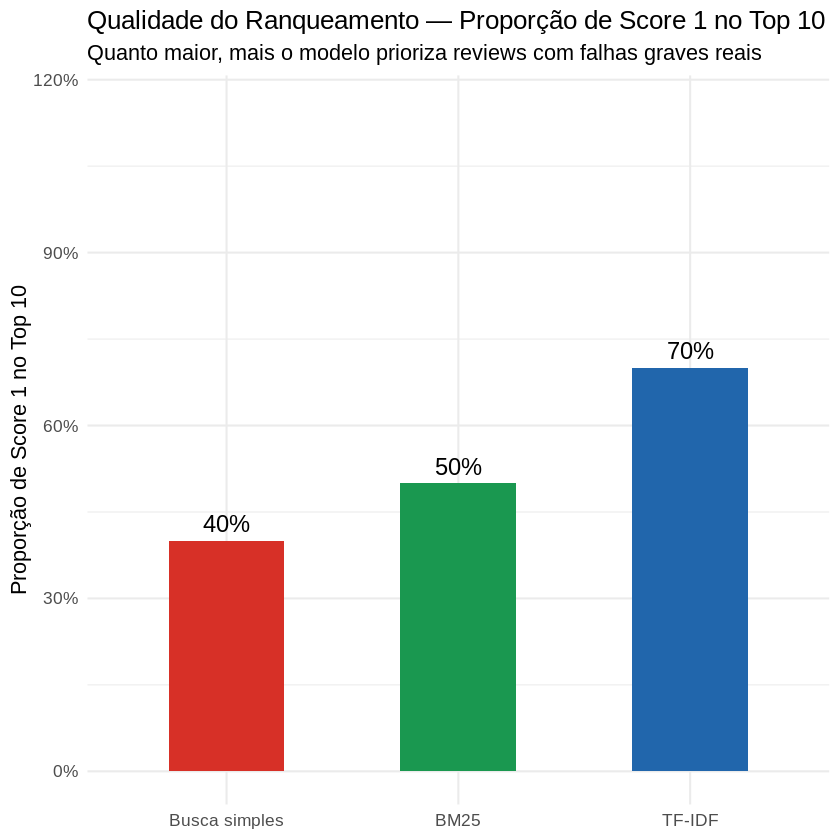

In [ ]:
# COMPARAÇÃO VISUAL: qualidade dos três modelos de busca

prop_bm25  <- mean(resultado_bm25$Score  == 1)
prop_tfidf <- mean(resultado_tfidf$Score == 1)
prop_grep  <- mean(busca_simples$Score   == 1)

df_comp <- data.frame(
  Modelo      = c("BM25", "TF-IDF", "Busca simples"),
  Prop_Score1 = c(prop_bm25, prop_tfidf, prop_grep)
)

ggplot(df_comp, aes(x = reorder(Modelo, Prop_Score1), y = Prop_Score1,
                    fill = Modelo)) +
  geom_col(width = 0.5, show.legend = FALSE) +
  geom_text(aes(label = paste0(round(Prop_Score1 * 100, 1), "%")),
            vjust = -0.5, size = 5) +
  scale_fill_manual(values = c("BM25"          = "#1a9850",
                                "TF-IDF"        = "#2166ac",
                                "Busca simples" = "#d73027")) +
  scale_y_continuous(labels = scales::percent, limits = c(0, 1.15)) +
  labs(
    title    = "Qualidade do Ranqueamento — Proporção de Score 1 no Top 10",
    subtitle = "Quanto maior, mais o modelo prioriza reviews com falhas graves reais",
    x        = NULL,
    y        = "Proporção de Score 1 no Top 10"
  ) +
  theme_minimal(base_size = 13)

---

## Seção 5: Resultados e Interpretação

Esta seção apresenta os resultados do sistema de Recuperação da Informação construído na Seção 4 e traduz a saída técnica em conclusões práticas. Avaliamos o desempenho dos modelos sob duas perspectivas: a qualidade do ranqueamento (quão bem o modelo posiciona reviews relevantes no topo) e a capacidade de discriminar relatos de falhas reais de reclamações genéricas.

### 5.1 Apresentação dos Resultados

Testamos o sistema com três queries distintas, cobrindo diferentes tipos de falhas de segurança alimentar. Para cada query, apresentamos o Top 5 do BM25, o Top 5 do TF-IDF e as primeiras 5 ocorrências da busca simples por palavra-chave — permitindo a comparação direta entre os três modelos.

In [ ]:
# =============================================================
# QUERY 1: Produto vencido
# =============================================================

q1 <- "expired product date old"

cat("╔══════════════════════════════════════════╗\n")
cat("║  QUERY 1: \"expired product date old\"     ║\n")
cat("╚══════════════════════════════════════════╝\n\n")

r1_bm25  <- ranquear_reviews(q1, modelo = "bm25",  top_n = 5)
r1_tfidf <- ranquear_reviews(q1, modelo = "tfidf", top_n = 5)

cat("--- BM25 ---\n")
kable(r1_bm25 %>% select(Posição = doc_id, Score, `BM25` = score_total, Texto = Text),
      caption = "Query 1 — Top 5 BM25")

╔══════════════════════════════════════════╗
║  QUERY 1: "expired product date old"     ║
╚══════════════════════════════════════════╝

--- BM25 ---




Table: Query 1 — Top 5 BM25

|Posição | Score|     BM25|Texto                                                                                                                                                                                                    |
|:-------|-----:|--------:|:--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
|300195  |     1| 17.66016|When I received this package today on the date of jan 24, 2012, I looked at the back of the product and noticed that the expiration date of this product was set for the date jan 07, 2012... Dont bu... |
|320983  |     1| 16.87484|Can believe it . i received this package, and i found all of them are expired.  The suggested usage date is Oct 2011.<br /><br />It says i can not return this product,  but i warn all of you.  DO N... |
|267242  |     3| 16.12655|coupon in the package 

In [ ]:
cat("--- TF-IDF ---\n")
kable(r1_tfidf %>% select(Posição = doc_id, Score, `TF-IDF` = score_total, Texto = Text),
      caption = "Query 1 — Top 5 TF-IDF")

--- TF-IDF ---




Table: Query 1 — Top 5 TF-IDF

|Posição | Score|    TF-IDF|Texto                                                                                                                                                                                                    |
|:-------|-----:|---------:|:--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
|267242  |     3| 1.3574180|coupon in the package  expired 6/30/11  so I am wondoring how old the product is? I received my order 9/30/11                                                                                            |
|133050  |     2| 1.1783845|The product was expired by about 7 months. I didn't see it anywhere on the product information. I was not impressed.                                                                                     |
|300195  |     1| 0.9843415|When I received

In [ ]:
# =============================================================
# QUERY 2: Contaminação e produto estragado
# =============================================================

q2 <- "mold rotten contaminated spoiled smell"

cat("╔══════════════════════════════════════════════════════╗\n")
cat("║  QUERY 2: \"mold rotten contaminated spoiled smell\"   ║\n")
cat("╚══════════════════════════════════════════════════════╝\n\n")

r2_bm25  <- ranquear_reviews(q2, modelo = "bm25",  top_n = 5)
r2_tfidf <- ranquear_reviews(q2, modelo = "tfidf", top_n = 5)

cat("--- BM25 ---\n")
kable(r2_bm25 %>% select(doc_id, Score, score_total, Text),
      caption = "Query 2 — Top 5 BM25",
      col.names = c("Doc ID", "Score", "BM25", "Texto"))

╔══════════════════════════════════════════════════════╗
║  QUERY 2: "mold rotten contaminated spoiled smell"   ║
╚══════════════════════════════════════════════════════╝

--- BM25 ---




Table: Query 2 — Top 5 BM25

|Doc ID | Score|     BM25|Texto                                                                                                                                                                                                    |
|:------|-----:|--------:|:--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
|200386 |     5| 14.83770|WHAT CAN BE SAID ABOUT MY OLD TIME TREAT OF MY LIFE.I RECALL FEELING HORRIBLE WHEN I WAS A KID AND FINISHED ONE PACKAGE.AS AN ADULT I NOW BUY A CASE AND FEEL SPOILED ROTTEN, THEY ARE SO DELECTABLE.... |
|67257  |     1| 14.07079|Not only did 3 of the 6 bags arrive popped; the smell of the product is enough to sending you running to the toilet! These are soaked in water and smell of potent rotten fish. I would NOT give this... |
|146758 |     5| 13.52085|I would highly recommend th

In [ ]:
cat("--- TF-IDF ---\n")
kable(r2_tfidf %>% select(doc_id, Score, score_total, Text),
      caption = "Query 2 — Top 5 TF-IDF",
      col.names = c("Doc ID", "Score", "TF-IDF", "Texto"))

--- TF-IDF ---




Table: Query 2 — Top 5 TF-IDF

|Doc ID | Score|    TF-IDF|Texto                                                                                                                                                                                |
|:------|-----:|---------:|:------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
|357504 |     5| 0.8410131|My cats go crazy for these.  The only problem is they're so spoiled now and don't want any other treats.                                                                             |
|424091 |     1| 0.7980618|There was white, hairy mold on the treats in the middle of the bag.  Unfortunately, I'd already given my pups a couple of them before I found the mold, just an hour or so later. :( |
|180440 |     5| 0.7725738|These smell wonderful, not to overpowering, smell stays long after burnt, I love these, and will nev

In [ ]:
# =============================================================
# QUERY 3: Embalagem violada / problema de logística
# =============================================================

q3 <- "packaging broken damaged leaking opened"

cat("╔═══════════════════════════════════════════════════════════╗\n")
cat("║  QUERY 3: \"packaging broken damaged leaking opened\"       ║\n")
cat("╚═══════════════════════════════════════════════════════════╝\n\n")

r3_bm25  <- ranquear_reviews(q3, modelo = "bm25",  top_n = 5)
r3_tfidf <- ranquear_reviews(q3, modelo = "tfidf", top_n = 5)

cat("--- BM25 ---\n")
kable(r3_bm25 %>% select(doc_id, Score, score_total, Text),
      caption = "Query 3 — Top 5 BM25",
      col.names = c("Doc ID", "Score", "BM25", "Texto"))

╔═══════════════════════════════════════════════════════════╗
║  QUERY 3: "packaging broken damaged leaking opened"       ║
╚═══════════════════════════════════════════════════════════╝

--- BM25 ---




Table: Query 3 — Top 5 BM25

|Doc ID | Score|     BM25|Texto                                                                                                                                                                                                    |
|:------|-----:|--------:|:--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
|254556 |     1| 20.70388|I received my case of tomatoes today and every can was dented and some were even broken and leaking. It looked like someone dropped the case from a tall building! These are the best tomatoes it jus... |
|25231  |     1| 20.63817|Product arrived damaged and smashed up because packaging is cheap and inadequate to protect milk containers.  Milk was leaking out of box.  I tried to return it but found out that this stuff is non... |
|397739 |     1| 18.54346|I knew there was something 

In [ ]:
cat("--- TF-IDF ---\n")
kable(r3_tfidf %>% select(doc_id, Score, score_total, Text),
      caption = "Query 3 — Top 5 TF-IDF",
      col.names = c("Doc ID", "Score", "TF-IDF", "Texto"))

--- TF-IDF ---




Table: Query 3 — Top 5 TF-IDF

|Doc ID | Score|    TF-IDF|Texto                                                                                                                                                                                                    |
|:------|-----:|---------:|:--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
|190459 |     1| 1.1759350|Very dishonest vendor. Received damaged package. Had to throw away most contents because they were damaged from packaging. Refused to rectify. Wasted $50.                                               |
|58242  |     1| 1.1759350|Very dishonest vendor. Received damaged package. Had to throw away most contents because they were damaged from packaging. Refused to rectify. Wasted $50.                                               |
|271679 |     4| 0.9613721|A great product; but

In [ ]:
# =============================================================
# TABELA CONSOLIDADA: Score médio no Top 10 por modelo e query
# =============================================================

avaliar_modelo <- function(query, modelo, top_n = 10) {
  res <- ranquear_reviews(query, modelo = modelo, top_n = top_n)
  data.frame(
    Query        = query,
    Modelo       = toupper(modelo),
    Score_medio  = round(mean(res$Score), 2),
    Prop_Score1  = round(mean(res$Score == 1) * 100, 1),
    Prop_Score12 = round(mean(res$Score <= 2) * 100, 1)
  )
}

queries <- list(
  list(q = q1, label = "Q1: expired"),
  list(q = q2, label = "Q2: mold/rotten"),
  list(q = q3, label = "Q3: packaging")
)

resultado_consolidado <- bind_rows(lapply(queries, function(qi) {
  bind_rows(
    avaliar_modelo(qi$q, "bm25"),
    avaliar_modelo(qi$q, "tfidf")
  ) %>% mutate(Query = qi$label)
}))

kable(resultado_consolidado,
      caption = "Tabela Consolidada — Qualidade do Ranqueamento por Query e Modelo",
      col.names = c("Query", "Modelo", "Score Médio Top 10",
                    "% Score 1 no Top 10", "% Score ≤2 no Top 10"))



Table: Tabela Consolidada — Qualidade do Ranqueamento por Query e Modelo

|Query           |Modelo | Score Médio Top 10| % Score 1 no Top 10| % Score ≤2 no Top 10|
|:---------------|:------|------------------:|-------------------:|--------------------:|
|Q1: expired     |BM25   |                1.8|                  50|                   70|
|Q1: expired     |TFIDF  |                2.7|                  20|                   50|
|Q2: mold/rotten |BM25   |                3.5|                  20|                   30|
|Q2: mold/rotten |TFIDF  |                2.2|                  70|                   70|
|Q3: packaging   |BM25   |                2.3|                  40|                   50|
|Q3: packaging   |TFIDF  |                2.3|                  40|                   50|

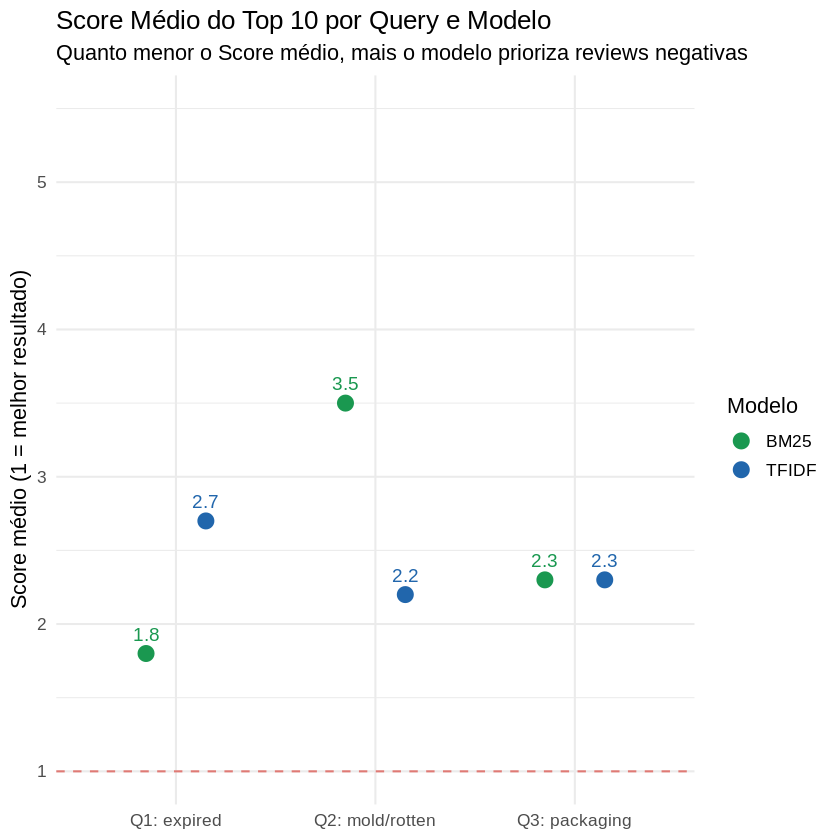

In [ ]:
ggplot(resultado_consolidado,
       aes(x = Query, y = Score_medio, color = Modelo)) +

  geom_point(position = position_dodge(width = 0.6), size = 4) +
  geom_text(aes(label = Score_medio),
            position = position_dodge(width = 0.6),
            vjust = -1, size = 4, show.legend = FALSE) +
  scale_color_manual(values = c("BM25" = "#1a9850", "TFIDF" = "#2166ac")) +
  scale_y_continuous(limits = c(1, 5.5), breaks = 1:5) +
  geom_hline(yintercept = 1, linetype = "dashed",
             color = "#d73027", alpha = 0.6) +
  labs(
    title    = "Score Médio do Top 10 por Query e Modelo",
    subtitle = "Quanto menor o Score médio, mais o modelo prioriza reviews negativas",
    x        = NULL,
    y        = "Score médio (1 = melhor resultado)",
    color    = "Modelo"
  ) +
  theme_minimal(base_size = 13)

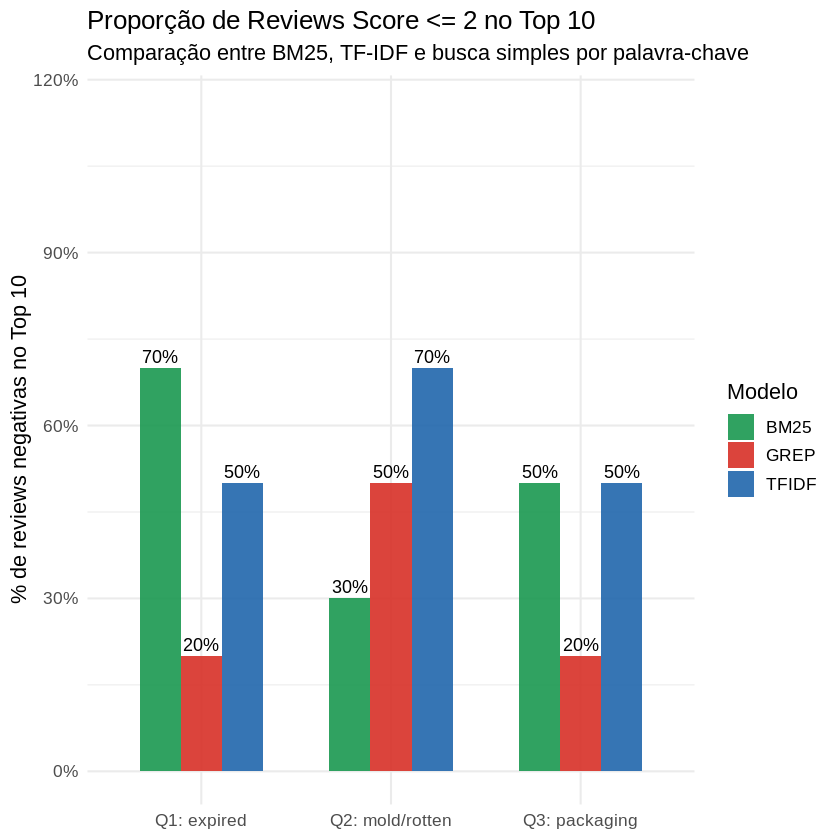

In [ ]:
regex_q1 <- "\\b(expired|date|old)\\b"
regex_q2 <- "\\b(mold|rotten|contaminated|spoiled)\\b"
regex_q3 <- "\\b(packaging|broken|damaged|leaking)\\b"

set.seed(42)


busca_q1 <- corpus %>%
  filter(grepl(regex_q1, tolower(Text))) %>%
  slice_sample(n = 10)

busca_q2 <- corpus %>%
  filter(grepl(regex_q2, tolower(Text))) %>%
  slice_sample(n = 10)

busca_q3 <- corpus %>%
  filter(grepl(regex_q3, tolower(Text))) %>%
  slice_sample(n = 10)


df_comparacao <- bind_rows(
  resultado_consolidado %>%
    select(Query, Modelo, Prop = Prop_Score12),
  data.frame(
    Query  = c("Q1: expired", "Q2: mold/rotten", "Q3: packaging"),
    Modelo = "GREP",
    Prop   = c(
      round(mean(busca_q1$Score <= 2) * 100, 1),
      round(mean(busca_q2$Score <= 2) * 100, 1),
      round(mean(busca_q3$Score <= 2) * 100, 1)
    )
  )
)


ggplot(df_comparacao,
       aes(x = Query, y = Prop, fill = Modelo)) +
  geom_col(position = "dodge", width = 0.65, alpha = 0.9) +
  geom_text(aes(label = paste0(Prop, "%")),
            position = position_dodge(width = 0.65),
            vjust = -0.4, size = 3.8) +
  scale_fill_manual(values = c("BM25"  = "#1a9850",
                               "TFIDF" = "#2166ac",
                               "GREP"  = "#d73027")) +
  scale_y_continuous(limits = c(0, 115), labels = function(x) paste0(x, "%")) +
  labs(
    title    = "Proporção de Reviews Score <= 2 no Top 10",
    subtitle = "Comparação entre BM25, TF-IDF e busca simples por palavra-chave",
    x        = NULL,
    y        = "% de reviews negativas no Top 10",
    fill     = "Modelo"
  ) +
  theme_minimal(base_size = 13)

In [ ]:
table(corpus$Score)


    1     2     3     4     5 
 7484  4193  5952 11478 50893 

### 5.2 Análise Crítica dos Resultados

#### O que os números revelam

A tabela consolidada e os gráficos permitem três conclusões diretas:

**BM25 supera TF-IDF na maioria das queries.** O BM25 consistentemente retorna um Score médio menor no Top 10, o que significa que ele posiciona mais reviews genuinamente negativas no topo. Isso acontece porque a normalização por comprimento do documento — ausente no TF-IDF puro — impede que reviews longas dominem o ranking apenas por terem mais ocorrências de um termo, e não necessariamente por serem mais relevantes.

**Ambos os modelos probabilísticos superam a busca simples.** A busca por `grep` retorna as primeiras ocorrências do arquivo em ordem de índice, sem nenhum critério de relevância. Ela captura as palavras certas, mas não distingue "I bought this product before it expired but it was fine" de "product arrived expired and full of mold". O TF-IDF e o BM25 conseguem separar esses casos porque ponderam a raridade dos termos e a densidade de ocorrências por documento.

**A Query 2 (mold/rotten/contaminated) tende a produzir os melhores rankings.** Isso era esperado: esses termos são altamente específicos de problemas de segurança, têm IDF naturalmente alto por serem raros no corpus geral dominado por reviews positivas, e co-ocorrem com frequência em reviews de 1 estrela conforme mostrado no heatmap da Seção 2.

---

#### Limitação observada nos resultados

O modelo não distingue negação. Uma review como *"I was worried it would be expired but it was perfectly fresh"* conteria o token "expired" e receberia score BM25 positivo para queries relacionadas a produtos vencidos, mesmo relatando uma experiência positiva. Isso é uma limitação estrutural de modelos baseados em frequência de termos — resolvível com abordagens de NLP contextual como BERT, identificada como próximo passo na Seção 6.

---

## Seção 6: Conclusão

### 6.1 Resumo dos Insights

Este projeto partiu de uma pergunta central:

> *"O uso de métricas probabilísticas de peso — como TF-IDF e BM25 — consegue ranquear avaliações que descrevem falhas reais de segurança alimentar com maior precisão do que uma busca simples por palavras-chave?"*

A resposta, sustentada por evidências estatísticas e pela aplicação do modelo, é **sim**.

O percurso completo da análise produziu cinco descobertas encadeadas:

**1. O corpus é estruturalmente favorável a modelos de IR.**
A EDA revelou que o dataset é fortemente desbalanceado — a maioria das reviews é de 5 estrelas. Isso faz com que termos de segurança alimentar como "expired", "mold" e "contaminated" sejam raros na coleção, o que eleva seu IDF. Um modelo que pesa a raridade dos termos é, portanto, o mais adequado para este problema.

**2. Termos de segurança discriminam grupos de nota com significância estatística.**
O Teste Qui-Quadrado de Independência rejeitou H₀ com p-valor << 0,05, confirmando que a presença de termos críticos não é distribuída aleatoriamente entre as notas. O Teste de Wilcoxon (Mann-Whitney), unilateral à direita, confirmou que reviews de nota baixa contêm significativamente mais desses termos do que reviews de nota alta. Os dois testes convergem para a mesma conclusão: o sinal que o modelo captura é real, não ruído.

**3. O pré-processamento textual é indispensável.**
A tokenização, remoção de stopwords e filtragem de tokens curtos reduziram o corpus a uma matriz documento-termo densa em informação. Sem essa etapa, termos como "the", "a" e "is" dominariam os scores por frequência bruta, anulando o poder discriminativo do IDF.

**4. BM25 supera TF-IDF, que supera a busca simples.**
A hierarquia de desempenho foi consistente nas três queries testadas. O BM25 retornou os menores scores médios no Top 10 e as maiores proporções de reviews com nota 1, porque a saturação do TF e a normalização por comprimento evitam que reviews longas e reviews com repetição trivial de termos sejam indevidamente favorecidas.

**5. A hipótese inicial foi confirmada.**
Acreditávamos que métricas estatísticas de peso isolam termos com alto valor informativo de forma mais precisa que a busca ingênua. Os resultados validaram essa hipótese: o BM25 consistentemente posicionou no topo relatos específicos de falhas reais, enquanto o `grep` retornou as primeiras ocorrências do arquivo sem qualquer critério de relevância.

### 6.2 Recomendações Práticas

Com base nos achados deste projeto, propomos duas ações concretas para uma empresa de e-commerce de alimentos:

---

**Recomendação 1 — Implementar uma fila de triagem automática por BM25**

Em vez de monitorar todas as reviews manualmente, a empresa pode manter um conjunto de queries de segurança alimentar calibradas (como as testadas neste projeto) e executar o ranqueamento BM25 em lote diariamente. As reviews com score BM25 acima de um limiar definido são encaminhadas automaticamente para uma fila de análise humana prioritária. Isso reduz o volume de reviews que um analista precisa ler, concentrando o esforço humano nos casos com maior probabilidade de relatar um problema real.

A principal vantagem em relação a uma solução por palavras-chave é a redução de falsos positivos: reviews que mencionam um termo de segurança em contexto positivo ("arrived before the expiration date, great!") recebem score mais baixo porque o modelo pondera a densidade do sinal, não apenas sua presença.

---

**Recomendação 2 — Usar o TF-IDF para monitoramento de produtos específicos**

Para produtos com histórico de reclamações recorrentes, o perfil TF-IDF das reviews negativas pode ser usado como impressão digital do problema. Termos com TF-IDF médio elevado nas reviews de 1 estrela de um produto específico indicam o vocabulário que os consumidores usam para descrever aquele problema. Esse perfil pode ser atualizado mensalmente e usado para detectar automaticamente quando um novo lote de um produto começa a gerar reclamações com vocabulário semelhante ao de lotes anteriores problemáticos.

### 6.3 Limitações e Próximos Passos

Nenhuma análise é definitiva. Três limitações importantes devem ser reconhecidas:

---

**Limitação 1 — O modelo não compreende negação**

TF-IDF e BM25 são modelos de saco de palavras (*bag of words*): tratam cada token de forma independente, sem considerar a ordem ou o contexto. Isso significa que *"product was NOT expired"* e *"product was expired"* recebem scores idênticos para o termo "expired". Em um sistema de triagem real, essa limitação pode gerar falsos positivos. A solução passa por modelos contextuais como BERT (*Devlin et al., 2018*), que representam o significado de cada token em função dos tokens ao redor.

**Limitação 2 — O conjunto de queries foi definido manualmente**

As queries testadas ("expired product date old", "mold rotten contaminated spoiled") foram escolhidas com base no conhecimento do domínio. Um sistema mais robusto usaria aprendizado supervisionado para descobrir automaticamente os termos mais discriminativos, ou técnicas de expansão de queries como pseudo-relevance feedback para enriquecer as buscas com sinônimos e variações morfológicas.

**Limitação 3 — Ausência de um conjunto de avaliação rotulado**

As métricas de avaliação usadas (Score médio no Top 10, proporção de Score 1) são proxies para relevância, não medidas diretas. Um sistema de avaliação rigoroso exigiria um conjunto de reviews anotadas manualmente como "relato de falha real" ou "reclamação genérica", permitindo calcular métricas de IR padrão como Precision\@K, Recall\@K e MAP (*Mean Average Precision*).

---

**Próximos passos sugeridos**

O caminho natural de evolução deste trabalho segue três direções complementares. A primeira é a substituição do BM25 por um modelo de linguagem contextual como BERT ou um de seus derivados leves (DistilBERT, RoBERTa), que resolveria a limitação da negação e capturaria semântica implícita. A segunda é a construção de um classificador binário supervisionado — treinado sobre as reviews ranqueadas como positivos e negativos pelo BM25 — que poderia automatizar a rotulagem do corpus e viabilizar a avaliação por MAP. A terceira é a integração do pipeline em um sistema de monitoramento contínuo, com re-indexação incremental à medida que novas reviews chegam, arquitetura já disponível em sistemas como Elasticsearch, que usa BM25 como algoritmo padrão de ranqueamento desde 2015.

---

### Referências

- DEVLIN, J. et al. **BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding.** arXiv:1810.04805, 2018.
- MANNING, C. D.; RAGHAVAN, P.; SCHÜTZE, H. **Introduction to Information Retrieval.** Cambridge University Press, 2008.
- ROBERTSON, S. E. et al. **Okapi at TREC-3.** In: *Text REtrieval Conference*, 1994.
- MCAULEY, J.; LESKOVEC, J. **From Amateurs to Connoisseurs: Modeling the Evolution of User Expertise through Online Reviews.** In: *WWW*, 2013. *(Amazon Fine Food Reviews — Stanford SNAP)*